<a href="https://colab.research.google.com/github/Geebigib/Data-Science-Project/blob/main/Probability_Base_Model_separate_stage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pyod --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 8.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import os
import pandas as pd
from glob import glob
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
import pickle
import tqdm
import matplotlib.pyplot as plt
from sklearn import metrics
import pyod
import seaborn as sns
import timeit
from sklearn.metrics import confusion_matrix

Data Pre-processing

In [4]:
# Load the available CSV files from the local directory
swat_normal = pd.read_csv("/content/drive/MyDrive/keerthi/FullNormal.csv")
swat_attack = pd.read_csv("/content/drive/MyDrive/keerthi/FullwithAttacks.csv")

In [5]:
swat_normal.columns = swat_normal.columns.str.replace(' ','')
swat_attack.columns = swat_attack.columns.str.replace(' ','')

In [6]:
swat_attack["Normal/Attack"].replace(' ', '', regex=True, inplace=True)

/tmp/ipython-input-2662746340.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  swat_attack["Normal/Attack"].replace(' ', '', regex=True, inplace=True)


In [7]:
test_df = swat_attack.set_index('Timestamp')
test_df['label'] = np.where(test_df['Normal/Attack'] == 'Attack', 1, 0)

test_df = test_df.drop('Normal/Attack', axis=1)

train_df = swat_normal.set_index('Timestamp')
train_df['label'] = np.where(train_df['Normal/Attack'] == 'Attack', 1, 0)
train_df = train_df.drop('Normal/Attack', axis=1)

# trim start stage
train_df = train_df.iloc[21600:]


In [8]:
train_df.drop(columns = 'label',inplace = True)
label = test_df['label'].values
test_df.drop(columns = 'label',inplace = True)

In [9]:
#normalise data
scaler = MinMaxScaler()
scaler = scaler.fit(train_df)

In [10]:
train_scale = pd.DataFrame(
    scaler.transform(train_df),
    index = train_df.index,
    columns= train_df.columns
)

test_scale  = pd.DataFrame(
    scaler.transform(test_df),
    index = test_df.index,
    columns= test_df.columns
)

In [11]:
train_scale.shape ,test_scale.shape

((473400, 51), (449919, 51))

In [12]:
train_df.columns

Index(['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202',
       'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205',
       'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303',
       'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401',
       'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504',
       'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501',
       'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603'],
      dtype='object')

In [13]:
P1 = ['FIT101', 'LIT101', 'MV101', 'P101', 'P102']
P2 = ['AIT201', 'AIT202','AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206']
P3 = ['DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302']
P4 = ['AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401']
P5 = ['AIT501', 'AIT502', 'AIT503', 'AIT504','FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501',
       'PIT502', 'PIT503']
P6 = ['FIT601', 'P601', 'P602', 'P603']

Model Prediction on each stage

In [14]:
from  pyod.models.ecod import ECOD
model = ECOD(contamination=0.000000001)

In [15]:
def get_test_score(stage,train_scale,test_scale):
  norm_test_scores = []
  test_scores = []
  train_scores = []
  norm_train_scores = []
  trainning_time = []
  prediction_time = []

  for i in stage:
    model = ECOD(contamination=0.000000001)
    start = timeit.default_timer()
    model.fit(train_scale[i])
    end = timeit.default_timer()

    train_score = model.decision_scores_
    start_pred = timeit.default_timer()
    test_score = model.decision_function(test_scale[i])
    end_pred = timeit.default_timer()

    test_scores.append(test_score)
    train_scores.append(train_score)

    trainning_time.append(end-start)
    prediction_time.append(end_pred-start_pred)

    #normalise train&test score
    min_train = min(train_score)
    max_train = max(train_score)
    norm_train = (train_score-min_train)/(max_train-min_train)
    norm_test = (test_score - min_train)/(max_train-min_train)

    norm_test_scores.append(norm_test)
    norm_train_scores.append(norm_train)

    print(f"------ Finish Stage {i} ------")
  return norm_test_scores,test_scores,train_scores,norm_train_scores,trainning_time,prediction_time


In [16]:
stage = [P1,P2,P3,P4,P5,P6]

In [17]:
norm_test_scores,test_scores,train_scores,norm_train_scores,trainning_time,prediction_time = get_test_score(stage,train_scale,test_scale)

------ Finish Stage ['FIT101', 'LIT101', 'MV101', 'P101', 'P102'] ------
------ Finish Stage ['AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206'] ------
------ Finish Stage ['DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302'] ------
------ Finish Stage ['AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401'] ------
------ Finish Stage ['AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503'] ------
------ Finish Stage ['FIT601', 'P601', 'P602', 'P603'] ------


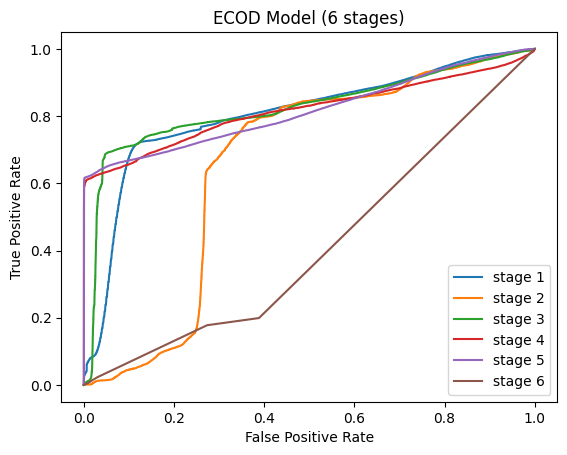

In [18]:
aucs = []
for i in range(len(norm_test_scores)):
  fpr, tpr, _ = metrics.roc_curve(label,  test_scores[i])
  auc = metrics.roc_auc_score(label,  test_scores[i])
  aucs.append(auc)
  plt.plot(fpr,tpr,label=f"stage {i+1}")
  plt.ylabel('True Positive Rate')
  plt.xlabel('False Positive Rate')
  plt.title(f'ECOD Model (6 stages)')
  plt.legend(loc=4)

In [19]:
for i in range(len(aucs)):
  print(f"AUC stage{i+1}: {np.round(aucs[i],3)}, training time = {trainning_time[i]}, prediction_time = {prediction_time[i]}")

AUC stage1: 0.805, training time = 1.6242091330000221, prediction_time = 1.3292467100000067
AUC stage2: 0.657, training time = 1.261257330000035, prediction_time = 2.7583193890000075
AUC stage3: 0.824, training time = 1.3228415029999496, prediction_time = 3.0471897250000666
AUC stage4: 0.818, training time = 1.3202527330000748, prediction_time = 2.3240996749999567
AUC stage5: 0.816, training time = 1.8352318160000323, prediction_time = 5.483563035999964
AUC stage6: 0.413, training time = 0.32908442699999796, prediction_time = 1.0095184129999097


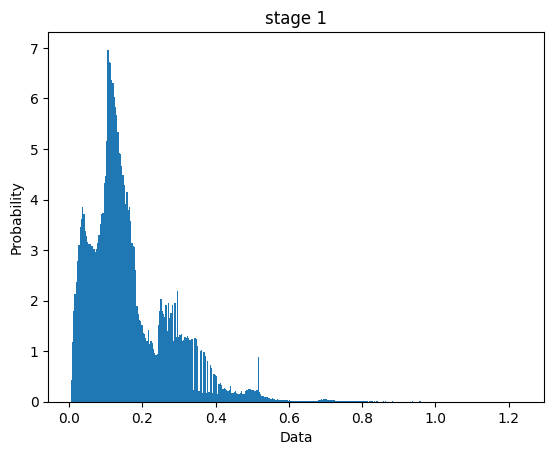

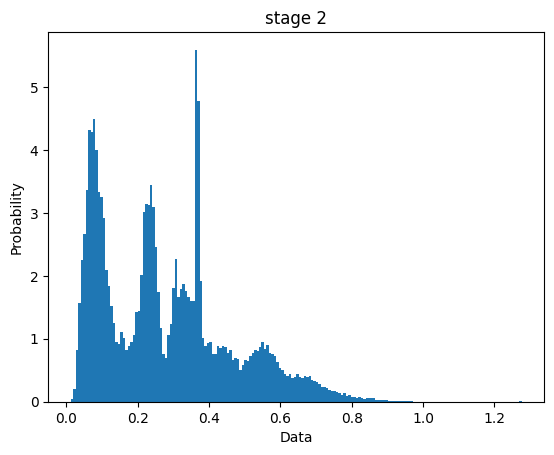

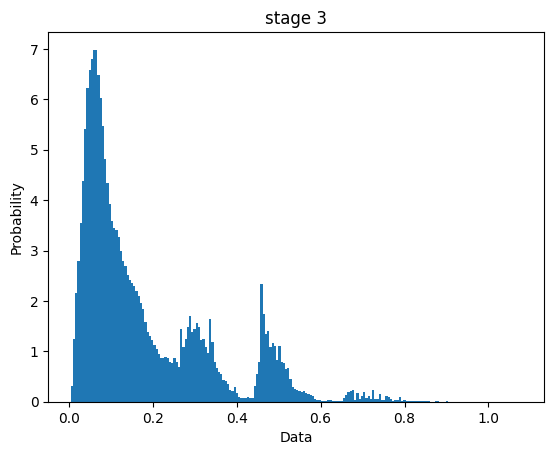

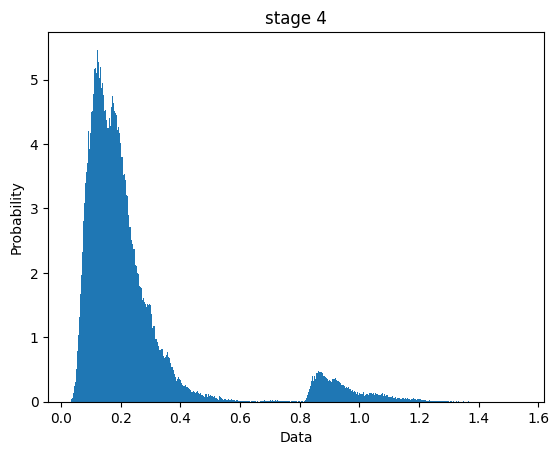

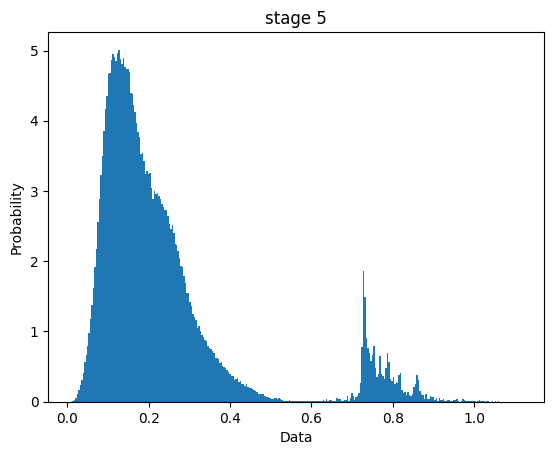

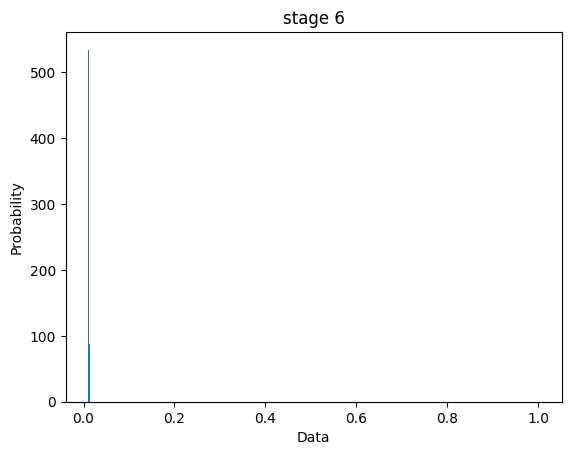

In [20]:
for i in range(len(norm_test_scores)):
  plt.hist(norm_test_scores[i], density=True, bins='auto')  # density=False would make counts
  plt.ylabel('Probability')
  plt.xlabel('Data')
  plt.title(f'stage {i+1}')
  plt.show()

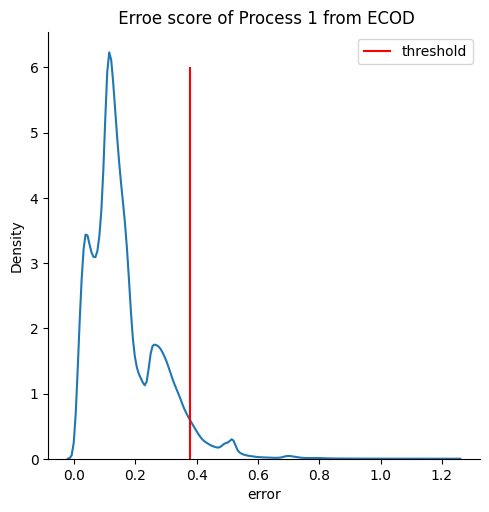

In [21]:
sns.displot(data=pd.DataFrame(norm_test_scores[0], columns = ['error']), x="error", kind="kde")
plt.title(' Erroe score of Process 1 from ECOD')
plt.vlines(np.percentile(norm_test_scores[0],95),ymin =0, ymax = 6,color = 'red', label = 'threshold')
plt.legend()

In [22]:
def pred_labels_timewindow(df,threshold,time_window):
  n_data = len(df)
  pred_label = np.array([_ for _ in range(n_data)])
  for i in range(0,n_data-time_window+1):
    if (df[i:i+time_window] >= threshold).any():
      pred_label[i:i+time_window] = 1
    else:
      pred_label[i:i+time_window] = 0

  return pred_label

In [23]:
time_window = 1

##Ture Attack point

In [24]:
true_anomaly = pd.read_csv("/content/drive/MyDrive/keerthi/List_of_attacks_Final.csv")

In [25]:
true_attack = true_anomaly[~true_anomaly["End Time"].isnull()]

In [26]:
true_attack.tail(3)

,Attack #,Start Time,End Time,Attack Point,Start State,Attack,Actual Change,Expected Impact or attacker intent,Unexpected Outcome,SEVERITY
38,39,02-01-2015 11:43,11:50:28,"FIT-401, AIT-502",In Normal Range,Set value of FIT-401 as 0.5; Set value of AIT-...,No,UV will shut down and water will go to RO,UV did not shutdown,LOW
39,40,02-01-2015 11:51,11:56:38,FIT-401,In Normal Range,Set value of FIT-401 as 0,No,UV will shut down and water will go to RO,"P-402 did not close, both should be interlinked",LOW
40,41,02-01-2015 13:13,13:40:56,LIT-301,Water level between L and H,decrease value by 0.5 mm per second,No,Tank overflow,Rate of decrease in water level reduced after ...,LOW


In [27]:
true_attack['Attack #']

,Attack #
0,1
1,2
2,3
3,4
5,6
6,7
7,8
9,10
10,11
12,13


In [28]:
start_time = true_attack['Start Time']
start_time = pd.to_datetime(start_time)
start_time.loc[36:40] = start_time.loc[36:40]+pd.DateOffset(years=1)

/tmp/ipython-input-2705936820.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  start_time = pd.to_datetime(start_time)


In [29]:
end_time = pd.to_datetime(true_anomaly['End Time'][~true_anomaly["End Time"].isnull()])

/tmp/ipython-input-1753609852.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  end_time = pd.to_datetime(true_anomaly['End Time'][~true_anomaly["End Time"].isnull()])


In [30]:
attack_lenght = (end_time - pd.to_datetime([str(a) for a in start_time.dt.time])).dt.seconds

/tmp/ipython-input-2947271413.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  attack_lenght = (end_time - pd.to_datetime([str(a) for a in start_time.dt.time])).dt.seconds


In [31]:
len(start_time) #there are 36 attack

36

In [32]:
n_att = start_time.index.values+1
start_time.index.values+1

array([ 1,  2,  3,  4,  6,  7,  8, 10, 11, 13, 14, 16, 17, 19, 20, 21, 22,
       23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39,
       40, 41])

In [33]:
label

array([0, 0, 0, ..., 0, 0, 0])

In [34]:
# time_label = pd.DataFrame(label, index =  test_df.index.values, columns = ["label"])
# time_label.reset_index(inplace=True)
# time_label.rename(columns = {'index':'Timestamp'}, inplace = True)
# time_label['Timestamp'] = pd.to_datetime(time_label['Timestamp'])
# Replace the problematic timestamp conversion with this corrected version:

time_label = pd.DataFrame(label, index=test_df.index.values, columns=["label"])
time_label.reset_index(inplace=True)
time_label.rename(columns={'index': 'Timestamp'}, inplace=True)

# Fix the timestamp parsing with mixed format and dayfirst=True
try:
    time_label['Timestamp'] = pd.to_datetime(time_label['Timestamp'], format='mixed', dayfirst=True)
    print("✅ Timestamps parsed successfully with mixed format")
except:
    # Fallback method if mixed format doesn't work
    print("⚠️ Using fallback timestamp parsing method...")
    time_label['Timestamp'] = pd.to_datetime(time_label['Timestamp'], infer_datetime_format=True, dayfirst=True)

print(f"Time label dataset created successfully")
print(f"Dataset shape: {time_label.shape}")
print(f"Sample timestamps: {time_label['Timestamp'].head()}")

✅ Timestamps parsed successfully with mixed format
Time label dataset created successfully
Dataset shape: (449919, 2)
Sample timestamps: 0   2015-12-28 10:00:00
1   2015-12-28 10:00:01
2   2015-12-28 10:00:02
3   2015-12-28 10:00:03
4   2015-12-28 10:00:04
Name: Timestamp, dtype: datetime64[ns]


In [35]:
time_label

,Timestamp,label
0,2015-12-28 10:00:00,0
1,2015-12-28 10:00:01,0
2,2015-12-28 10:00:02,0
3,2015-12-28 10:00:03,0
4,2015-12-28 10:00:04,0
...,...,...
449914,2016-01-02 14:59:55,0
449915,2016-01-02 14:59:56,0
449916,2016-01-02 14:59:57,0
449917,2016-01-02 14:59:58,0


In [36]:
#find start index/ end index of attack
idx_start = time_label[time_label['Timestamp'].isin(start_time)]['Timestamp'].index.values
idx_end = idx_start+attack_lenght.values

In [37]:
idx_start

array([  1740,   3060,   4920,   6420,   7200,   7680,  11400,  15360,
        15540,  90660,  92100,  93420, 103080, 115800, 116100, 117000,
       132900, 142920, 172260, 172860, 198240, 227820, 229500, 279120,
       280020, 302619, 347679, 361179, 371439, 371799, 389679, 436539,
       437379, 438099, 438579, 443499])

In [38]:
time_label['attack #'] = 0
for i in range (len(n_att)):
  time_label['attack #'].loc[idx_start[i]:idx_end[i]] = n_att[i]

/tmp/ipython-input-2116760698.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_label['attack #'].loc[idx_start[i]:idx_end[i]] = n_att[i]
/tmp/ipython-input-2116760698.py:3: SettingWithCopyWarning: 
A value is trying to be set on a co

##tunning threshold from stage P1

In [39]:
!pip install ghostml --quiet

In [40]:
import ghostml
n_percentile = [np.percentile(norm_test_scores,i) for i in range(95,100,1)]

In [41]:
threshold1 = ghostml.optimize_threshold_from_predictions(label, norm_test_scores[0], n_percentile, ThOpt_metrics = 'Kappa')

In [42]:
threshold1

np.float64(0.5425581102041063)

In [43]:
n_percentile #use percentil 95

[np.float64(0.5425581102041063),
 np.float64(0.5972893115948498),
 np.float64(0.7018283535103061),
 np.float64(0.7655523500483444),
 np.float64(0.8733564421719269)]

##Stage P1

In [44]:
t1 = np.percentile(norm_test_scores[0],95)

In [45]:
label_1 = pred_labels_timewindow(norm_test_scores[0],t1,time_window)

In [46]:
time_label["pred_1"] = label_1

In [47]:
att_p1 = time_label[time_label['attack #'].isin([1,2,3,21,26,30,33,34,35,36])]

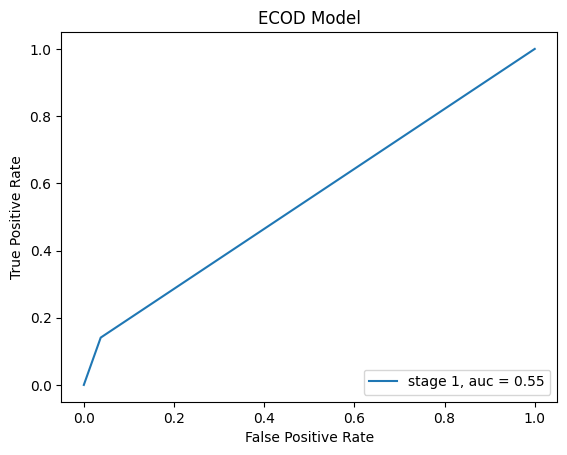

In [48]:
fpr, tpr, _ = metrics.roc_curve(label, label_1)
auc = metrics.roc_auc_score(label, label_1)
plt.plot(fpr,tpr,label=f"stage 1, auc = {np.round(auc,2)}")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title(f'ECOD Model')
plt.legend(loc=4)

In [49]:
print(metrics.classification_report(label,label_1))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92    395298
           1       0.34      0.14      0.20     54621

    accuracy                           0.86    449919
   macro avg       0.62      0.55      0.56    449919
weighted avg       0.82      0.86      0.84    449919



[[380495  14803]
 [ 46928   7693]]


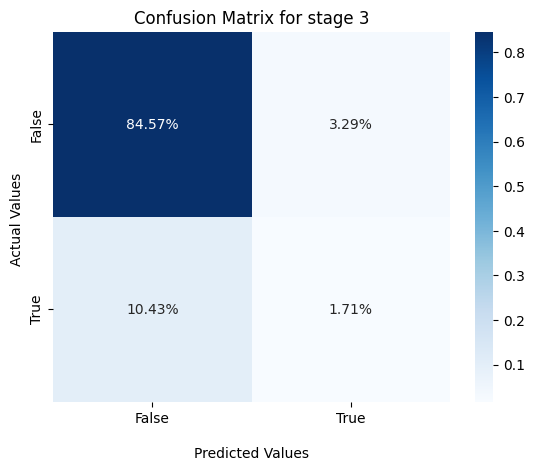

In [50]:
cm = confusion_matrix(label,label_1)
print(cm)
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for stage 3');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [51]:
print(metrics.classification_report(att_p1.label,att_p1.pred_1))

              precision    recall  f1-score   support

           0       0.08      0.76      0.14       227
           1       0.99      0.70      0.82      6669

    accuracy                           0.70      6896
   macro avg       0.53      0.73      0.48      6896
weighted avg       0.96      0.70      0.80      6896



In [52]:
found = []
for i in range(len(att_p1)):
  if (att_p1.iloc[i]["pred_1"] == 1) & (att_p1.iloc[i]["label"] == 1):
    found.append(att_p1.iloc[i]["attack #"])
print(np.unique(found))

[ 1  2  3 26 30 33 34 35 36]


In [53]:
np.unique(att_p1["attack #"])

array([ 1,  2,  3, 21, 26, 30, 33, 34, 35, 36])

##Stage P2

In [54]:
t2 = np.percentile(norm_test_scores[1],95)

In [55]:
t2

np.float64(0.6319771843423068)

In [56]:
label_2 = pred_labels_timewindow(norm_test_scores[1],t2,time_window)

In [57]:
print(metrics.classification_report(label,label_2))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91    395298
           1       0.04      0.01      0.02     54621

    accuracy                           0.83    449919
   macro avg       0.46      0.48      0.46    449919
weighted avg       0.77      0.83      0.80    449919



[[373612  21686]
 [ 53809    812]]


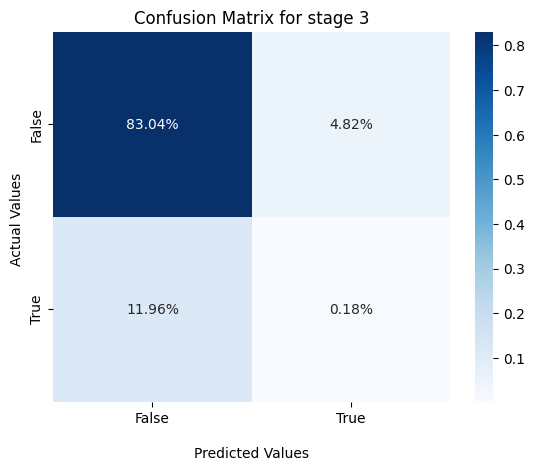

In [58]:
cm = confusion_matrix(label,label_2)
print(cm)
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for stage 3');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [59]:
time_label["pred_2"] = label_2

In [60]:
att_p2 = time_label[time_label['attack #'].isin([6,24,29])]

In [61]:
found = []
for i in range(len(att_p2)):
  if (att_p2.iloc[i]["pred_2"] == 1) & (att_p2.iloc[i]["label"] == 1):
    found.append(att_p2.iloc[i]["attack #"])
print(np.unique(found))

[24]


In [62]:
print(metrics.classification_report(att_p2.label,att_p2.pred_2))

              precision    recall  f1-score   support

           0       0.10      1.00      0.18        63
           1       1.00      0.09      0.16       638

    accuracy                           0.17       701
   macro avg       0.55      0.54      0.17       701
weighted avg       0.92      0.17      0.16       701



##Stage P3

In [63]:
t3 = np.percentile(norm_test_scores[2],95)

In [64]:
t3

np.float64(0.5000176847302945)

In [65]:
label_3 = pred_labels_timewindow(norm_test_scores[2],t3,time_window)

In [66]:
print(metrics.classification_report(label,label_3))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94    395298
           1       0.59      0.25      0.35     54621

    accuracy                           0.89    449919
   macro avg       0.75      0.61      0.64    449919
weighted avg       0.87      0.89      0.87    449919



[[386068   9230]
 [ 41093  13528]]


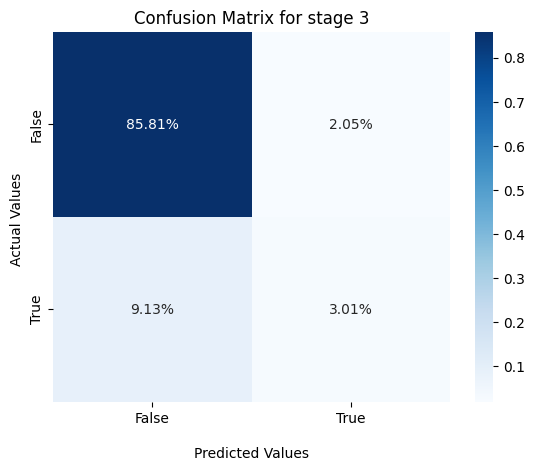

In [67]:
cm = confusion_matrix(label,label_3)
print(cm)
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for stage 3');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [68]:
time_label["pred_3"] = label_3

In [69]:
att_p3 = time_label[time_label['attack #'].isin([7,8,13,14,16,17,23,26,27,28,32,41])]

In [70]:
found = []
for i in range(len(att_p3)):
  if (att_p3.iloc[i]["pred_3"] == 1) & (att_p3.iloc[i]["label"] == 1):
    found.append(att_p3.iloc[i]["attack #"])
print(np.unique(found))

[ 8 17 23 26 28 41]


In [71]:
print(metrics.classification_report(att_p3.label,att_p3.pred_3))

              precision    recall  f1-score   support

           0       0.01      0.96      0.01       237
           1       1.00      0.31      0.47     43368

    accuracy                           0.31     43605
   macro avg       0.50      0.63      0.24     43605
weighted avg       0.99      0.31      0.47     43605



##Stage P4

In [72]:
t4 = np.percentile(norm_test_scores[3],95)

In [73]:
t4

np.float64(0.88146851946665)

In [74]:
label_4 = pred_labels_timewindow(norm_test_scores[3],t4,time_window)

In [75]:
print(metrics.classification_report(label,label_4))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96    395298
           1       1.00      0.41      0.58     54621

    accuracy                           0.93    449919
   macro avg       0.96      0.71      0.77    449919
weighted avg       0.93      0.93      0.91    449919



[[395217     81]
 [ 32205  22416]]


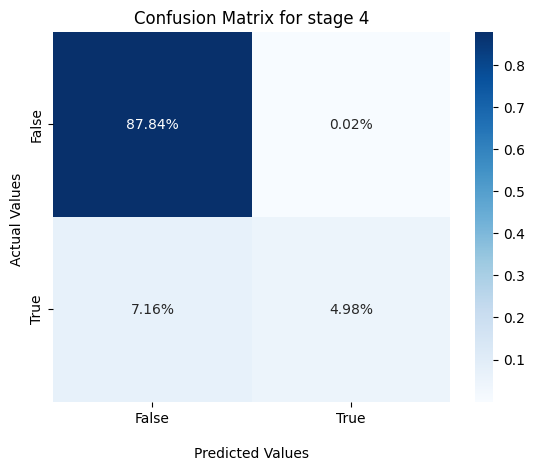

In [76]:
cm = confusion_matrix(label,label_4)
print(cm)
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for stage 4');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [77]:
time_label["pred_4"] = label_4

In [78]:
att_p4 = time_label[time_label['attack #'].isin([10,11,22,25,31,38,39,40])]

In [79]:
found = []
for i in range(len(att_p4)):
  if (att_p4.iloc[i]["pred_4"] == 1) & (att_p4.iloc[i]["label"] == 1):
    found.append(att_p4.iloc[i]["attack #"])
print(np.unique(found))

[]


In [80]:
print(metrics.classification_report(att_p4.label,att_p4.pred_4))

              precision    recall  f1-score   support

           0       0.07      1.00      0.14       250
           1       0.00      0.00      0.00      3142

    accuracy                           0.07      3392
   macro avg       0.04      0.50      0.07      3392
weighted avg       0.01      0.07      0.01      3392



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Stage P5

In [81]:
t5 = np.percentile(norm_test_scores[4],95)

In [82]:
t5

np.float64(0.7405769366892967)

In [83]:
label_5 = pred_labels_timewindow(norm_test_scores[4],t5,time_window)

In [84]:
print(metrics.classification_report(label,label_5))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96    395298
           1       0.99      0.41      0.58     54621

    accuracy                           0.93    449919
   macro avg       0.96      0.70      0.77    449919
weighted avg       0.93      0.93      0.91    449919



[[395126    172]
 [ 32295  22326]]


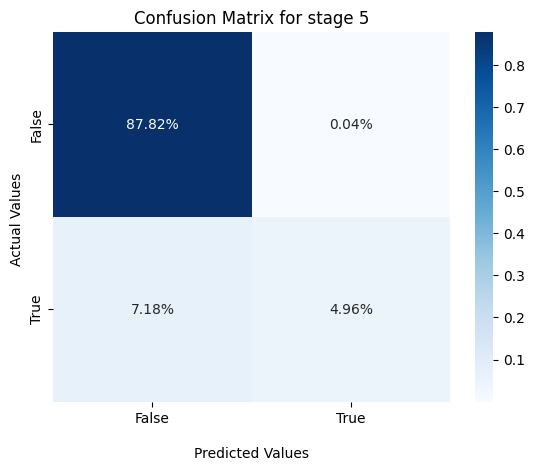

In [85]:
cm = confusion_matrix(label,label_5)
print(cm)
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for stage 5');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [86]:
time_label["pred_5"] = label_5

In [87]:
att_p5 = time_label[time_label['attack #'].isin([4,19,20,22,37,38,39])]

In [88]:
found = []
for i in range(len(att_p5)):
  if (att_p5.iloc[i]["pred_5"] == 1) & (att_p5.iloc[i]["label"] == 1):
    found.append(att_p5.iloc[i]["attack #"])
print(np.unique(found))

[22 37]


In [89]:
print(metrics.classification_report(att_p5.label,att_p5.pred_5))

              precision    recall  f1-score   support

           0       0.08      1.00      0.15       229
           1       1.00      0.05      0.09      2658

    accuracy                           0.12      2887
   macro avg       0.54      0.52      0.12      2887
weighted avg       0.93      0.12      0.09      2887



##Stage P6

In [90]:
t6 = np.percentile(norm_test_scores[5],98)

In [91]:
t6

np.float64(0.1774254625989767)

In [92]:
label_6 = pred_labels_timewindow(norm_test_scores[5],t6,time_window)

In [93]:
print(metrics.classification_report(label,label_6))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92    395298
           1       0.10      0.02      0.04     54621

    accuracy                           0.85    449919
   macro avg       0.49      0.50      0.48    449919
weighted avg       0.78      0.85      0.81    449919



[[383369  11929]
 [ 53364   1257]]


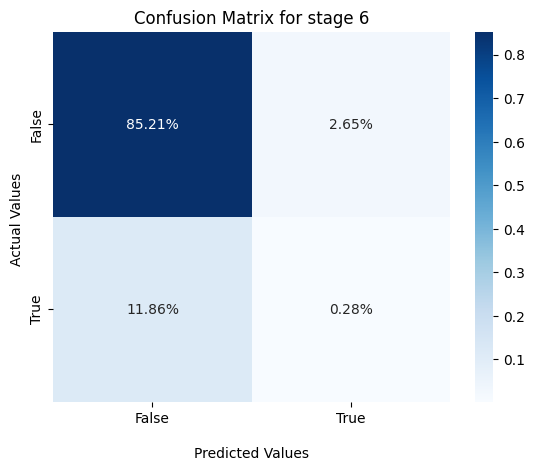

In [94]:
cm = confusion_matrix(label,label_6)
print(cm)
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for stage 6');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [95]:
time_label["pred_6"] = label_6

In [96]:
att_p6 = time_label[time_label['attack #'].isin([23])]

In [97]:
found = []
for i in range(len(att_p6)):
  if (att_p6.iloc[i]["pred_6"] == 1) & (att_p6.iloc[i]["label"] == 1):
    found.append(att_p6.iloc[i]["attack #"])
print(np.unique(found))

[23]


In [98]:
print(metrics.classification_report(att_p6.label,att_p6.pred_6))

              precision    recall  f1-score   support

           0       0.05      1.00      0.09        34
           1       1.00      0.03      0.06       697

    accuracy                           0.08       731
   macro avg       0.52      0.52      0.08       731
weighted avg       0.96      0.08      0.07       731



[[ 34   0]
 [674  23]]


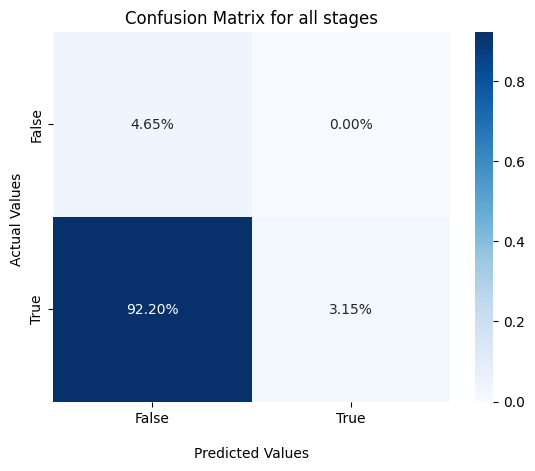

In [99]:
cm = confusion_matrix(att_p6.label,att_p6.pred_6)

print(cm)
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for all stages');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

##Attack found

In [102]:
time_label['pred'] = np.where((time_label['pred_1'] ==1) |
                              (time_label['pred_2'] ==1) |
                              (time_label['pred_3'] ==1) |
                              (time_label['pred_4'] ==1) |
                              (time_label['pred_5'] ==1) |
                              (time_label['pred_6'] ==1), 1, 0)


In [103]:
time_label[time_label["label"] == 1].tail(5)

,Timestamp,label,attack #,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred
445186,2016-01-02 13:41:07,1,0,0,0,1,0,0,0,1
445187,2016-01-02 13:41:08,1,0,0,0,1,0,0,0,1
445188,2016-01-02 13:41:09,1,0,0,0,1,0,0,0,1
445189,2016-01-02 13:41:10,1,0,0,0,1,0,0,0,1
445190,2016-01-02 13:41:11,1,0,0,0,1,0,0,0,1


In [105]:
time_label['found'] = 0
t = 100
for i in range(0,len(time_label)-t):
  if ((time_label['pred'][i:i+t]) == 1).all():
    time_label['found'][i:i+t] = 1

Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-3941574780.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_label['found'][i:i+t] = 1
/tmp/ipython-input-3941574780.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_label['found'][i:i+t] = 1
/tmp/ipython-input-3941574780.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_label['found'][i:i+t] = 1
/tmp/ipython-input-3941574780.py:5: SettingWithCo

In [106]:
found = []
for i in range(len(time_label)):
  if (time_label.iloc[i]["found"] == 1) & (time_label.iloc[i]["label"] == 1):
    found.append(time_label.iloc[i]["attack #"])
print(np.unique(found))

[ 0  1  2  3  8 11 17 19 21 22 23 24 26 28 30 33 34 35 36 37 38 40 41]


In [107]:
len(np.unique(found))-1 #remove 0

22

In [108]:
print(metrics.classification_report(time_label.label,time_label.found))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93    395298
           1       0.48      0.60      0.53     54621

    accuracy                           0.87    449919
   macro avg       0.71      0.76      0.73    449919
weighted avg       0.89      0.87      0.88    449919



In [109]:
cm = confusion_matrix(time_label.label,time_label.found)

print(cm)

[[359384  35914]
 [ 21676  32945]]


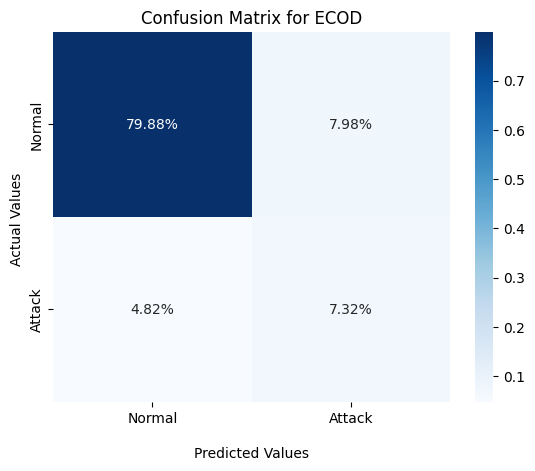

In [110]:
ax = sns.heatmap(cm/np.sum(cm), annot=True,
            fmt='.2%', cmap='Blues')

ax.set_title('Confusion Matrix for ECOD');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Normal','Attack'])
ax.yaxis.set_ticklabels(['Normal','Attack'])

## Display the visualization of the Confusion Matrix.
plt.show()

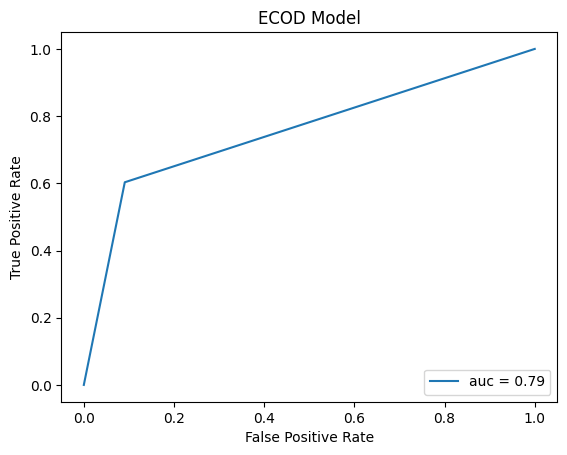

In [111]:
fpr, tpr, _ = metrics.roc_curve(time_label.label,time_label.found)
auc = metrics.roc_auc_score(time_label.label,time_label.pred)
plt.plot(fpr,tpr,label=f"auc = {np.round(auc,2)}")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.title(f'ECOD Model')
plt.legend(loc=4)

In [112]:
time_label[idx_start[14]:]

,Timestamp,label,attack #,pred_1,pred_2,pred_3,pred_4,pred_5,pred_6,pred,found
116100,2015-12-29 18:15:00,1,20,0,0,0,0,0,0,0,0
116101,2015-12-29 18:15:01,1,20,0,0,0,0,0,0,0,0
116102,2015-12-29 18:15:02,0,20,0,0,0,0,0,0,0,0
116103,2015-12-29 18:15:03,0,20,0,0,0,0,0,0,0,0
116104,2015-12-29 18:15:04,0,20,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
449914,2016-01-02 14:59:55,0,0,0,1,0,0,0,0,1,1
449915,2016-01-02 14:59:56,0,0,0,1,0,0,0,0,1,1
449916,2016-01-02 14:59:57,0,0,0,1,0,0,0,0,1,1
449917,2016-01-02 14:59:58,0,0,0,1,0,0,0,0,1,1


#XAI

In [ ]:
att_found = np.unique(found)
att_found

In [ ]:
!pip install shap --quiet
!pip install lime --quiet
!pip install alibi[tensorflow] --quiet

In [ ]:
import shap
import lime
import lime.lime_tabular
from lime import submodular_pick
#from alibi.explainers import ALE

In [ ]:
X_train_summary = shap.kmeans(train_scale, 100)
shap_explainer = shap.KernelExplainer(model=model.decision_function, data=X_train_summary)
#ale = ALE(model.decision_function, feature_names=train_scale.columns)
lm = lime.lime_tabular.LimeTabularExplainer(X_train_summary.data, feature_names=train_scale.columns,
                                                   verbose=True, mode='regression')

In [ ]:
def explain_all_attack(att_found,test_scale):
  shap_values = []
  limes = []
  #ales = []
  for i in att_found:
    idx = time_label[(time_label["attack #"] == i)].index.values
    n = 100 if len(idx) > 100 else len(idx)
    sample = test_scale[idx[0]:idx[-1]].sample(n = n)
    #shap explainer
    shap_value = shap_explainer.shap_values(X=sample, nsamples=100)
    shap_values.append(np.mean(shap_value,axis=0))

    #lime
    sp_obj = submodular_pick.SubmodularPick(lm, sample.values, model.decision_function, num_features=20,num_exps_desired=1)
    limes.append(sp_obj.sp_explanations[0].as_list())

    #ale
    # exp_ale = ale.explain(sample.to_numpy())
    # ales.append([np.mean(e) for e in exp_ale.ale_values])

    print(f"---------------------------------- finish XAI attack no {i} ----------------------------")

  return shap_values,limes,ales

In [ ]:
shap_values,limes,ales = explain_all_attack(att_found,test_scale)

In [ ]:
#save result
path = '/content/drive/MyDrive/Data_sci_Project/XAI_result'

In [ ]:
import pickle

xai_re = {'shap_values':shap_values,"limes":limes,"ales":ales}

with open(path+'deep_svdd_xai.pkl', 'wb') as fid:
     pickle.dump(xai_re, fid)

## **SEVERITY SCORING**

In [113]:
# Severity Analysis for Detected Attacks
print("=== SEVERITY ANALYSIS FOR DETECTED ATTACKS ===")

# Define component safety criticality
component_safety_criticality = {
    # L1 - High Critical (1.0)
    'P-102': 1.0, 'P102': 1.0,  # Main process pump
    'MV-101': 1.0, 'MV101': 1.0,  # Primary motorized valve
    'LIT-101': 1.0, 'LIT101': 1.0,  # Level indicator transmitter
    'P-101': 1.0, 'P101': 1.0,  # Raw water intake pump
    'P-602': 1.0, 'P602': 1.0,  # RO high pressure pump


    # L2 - Medium Critical (0.7)
    'MV-304': 0.7, 'MV304': 0.7,  # Ultrafiltration motorized valve
    'MV-303': 0.7, 'MV303': 0.7,  # Ultrafiltration motorized valve
    'DPIT-301': 0.7, 'DPIT301': 0.7, # Differential pressure indicator
    'MV-302': 0.7, 'MV302': 0.7,  # Ultrafiltration motorized valve
    'MV-201': 0.7, 'MV201': 0.7,  # Chemical dosing valve
    'LIT-401': 0.7, 'LIT401': 0.7, # Level indicator transmitter
    'LIT-301': 0.7, 'LIT301': 0.7, # Level indicator transmitter
    'FIT-601': 0.7, 'FIT601': 0.7,  # RO high pressure pump
    'AIT-501': 0.7, 'AIT501': 0.7,


    # L3 - Low Critical (0.2) - All remaining components
    'FIT101': 0.2, 'AIT101': 0.2, 'AIT102': 0.2, 'AIT103': 0.2,
    'MV301': 0.2, 'AIT301': 0.2, 'AIT302': 0.2, 'AIT303': 0.2,
    'P301': 0.2, 'P302': 0.2, 'AIT401': 0.2, 'AIT402': 0.2,
    'FIT401': 0.2, 'UV401': 0.2, 'P401': 0.2, 'P402': 0.2,
    'P403': 0.2, 'P404': 0.2,'AIT503': 0.2, 'AIT504': 0.2, 'FIT501': 0.2, 'FIT502': 0.2,
    'FIT503': 0.2, 'FIT504': 0.2, 'P501': 0.2, 'P502': 0.2,
    'PIT501': 0.2, 'PIT502': 0.2, 'PIT503': 0.2, 'AIT601': 0.2,
    'AIT602': 0.2, 'AIT603': 0.2,'P601': 0.2,
    'P603': 0.2,  'PIT602': 0.2, 'PIT603': 0.2,
    'AIT202': 0.2, 'MV504': 0.2, 'P203': 0.2, 'P201': 0.2, 'P205': 0.2,
    'AIT-502': 0.2, 'AIT502': 0.2,

}

# Define stage weights
stage_weights = {
    'P1': 0.8,   # Raw water intake - critical
    'P2': 0.6,   # Chemical dosing - most critical
    'P3': 0.7,   # Ultrafiltration - important
    'P4': 0.5,   # UV disinfection - least critical
    'P5': 0.3,   # Reverse osmosis - low critical
    'P6': 0.4    # Drainage - moderate critical
}

# Create component to stage mapping
component_to_stage = {}
for component in P1:
    component_to_stage[component] = 'P1'
    component_to_stage[component.replace('101', '-101')] = 'P1'
    component_to_stage[component.replace('102', '-102')] = 'P1'
for component in P2:
    component_to_stage[component] = 'P2'
    component_to_stage[component.replace('20', '-20')] = 'P2'
for component in P3:
    component_to_stage[component] = 'P3'
    component_to_stage[component.replace('30', '-30')] = 'P3'
for component in P4:
    component_to_stage[component] = 'P4'
    component_to_stage[component.replace('40', '-40')] = 'P4'
for component in P5:
    component_to_stage[component] = 'P5'
    component_to_stage[component.replace('50', '-50')] = 'P5'
for component in P6:
    component_to_stage[component] = 'P6'
    component_to_stage[component.replace('60', '-60')] = 'P6'

print("Component safety criticality and stage mapping defined successfully")

=== SEVERITY ANALYSIS FOR DETECTED ATTACKS ===
Component safety criticality and stage mapping defined successfully


In [114]:
# Attack point mapping from List_of_attacks_Final.csv
attack_points = {
    1.0: 'MV101',     # Attack 1: MV-101
    2.0: 'P102',      # Attack 2: P-102
    3.0: 'LIT101',    # Attack 3: LIT-101
    4.0: 'MV504',     # Attack 4: MV-504
    6.0: 'AIT202',    # Attack 6: AIT-202
    7.0: 'LIT301',    # Attack 7: LIT-301
    8.0: 'DPIT301',   # Attack 8: DPIT-301
    10.0: 'FIT401',   # Attack 10: FIT-401
    11.0: 'FIT401',   # Attack 11: FIT-401
    13.0: 'MV304',    # Attack 13: MV-304
    14.0: 'MV303',    # Attack 14: MV-303
    16.0: 'LIT301',   # Attack 16: LIT-301
    17.0: 'MV303',    # Attack 17: MV-303
    19.0: 'AIT504',   # Attack 19: AIT-504
    20.0: 'AIT504',   # Attack 20: AIT-504
    21.0: 'MV101',    # Attack 21: MV-101 (multi-point, using primary)
    22.0: 'UV401',    # Attack 22: UV-401 (multi-point, using primary)
    23.0: 'P602',     # Attack 23: P-602 (multi-point, using primary)
    24.0: 'P203',     # Attack 24: P-203 (multi-point, using primary)
    25.0: 'LIT401',   # Attack 25: LIT-401 (multi-point, using primary)
    26.0: 'P101',     # Attack 26: P-101 (multi-point, using primary)
    27.0: 'P302',     # Attack 27: P-302 (multi-point, using primary)
    28.0: 'P302',     # Attack 28: P-302
    29.0: 'P201',     # Attack 29: P-201 (multi-point, using primary)
    30.0: 'LIT101',   # Attack 30: LIT-101 (multi-point, using primary)
    31.0: 'LIT401',   # Attack 31: LIT-401
    32.0: 'LIT301',   # Attack 32: LIT-301
    33.0: 'LIT101',   # Attack 33: LIT-101
    34.0: 'P101',     # Attack 34: P-101
    35.0: 'P101',     # Attack 35: P-101 (multi-point, using primary)
    36.0: 'LIT101',   # Attack 36: LIT-101
    37.0: 'P501',     # Attack 37: P-501 (multi-point, using primary)
    38.0: 'AIT402',   # Attack 38: AIT-402 (multi-point, using primary)
    39.0: 'FIT401',   # Attack 39: FIT-401 (multi-point, using primary)
    40.0: 'FIT401',   # Attack 40: FIT-401
    41.0: 'LIT301'    # Attack 41: LIT-301
}

print(f"Attack point mapping defined for {len(attack_points)} attacks")

Attack point mapping defined for 36 attacks


In [115]:
# Ground Truth Severity Mapping from List_of_attacks_Final.csv
ground_truth_severity = {
    1: 'MEDIUM',    # Attack 1: MV-101 - Tank overflow
    2: 'SEVERE',    # Attack 2: P-102 - Pipe bursts
    3: 'LOW',       # Attack 3: LIT-101 - Increase by 1 mm every second
    4: 'LOW',       # Attack 4: MV-504 - Open MV-504
    6: 'LOW',       # Attack 6: AIT-202 - Set value as 6
    7: 'LOW',       # Attack 7: LIT-301 - Water level increased above HH
    8: 'LOW',       # Attack 8: DPIT-301 - Set value >40kpa
    10: 'LOW',      # Attack 10: FIT-401 - Set value <0.7
    11: 'LOW',      # Attack 11: FIT-401 - Set value as 0
    13: 'LOW',      # Attack 13: MV-304 - Close MV-304
    14: 'LOW',      # Attack 14: MV-303 - Do not let open
    16: 'LOW',      # Attack 16: LIT-301 - Decrease by 1mm each second
    17: 'MEDIUM',   # Attack 17: MV-303 - Do not let open
    19: 'LOW',      # Attack 19: AIT-504 - Set to 16 uS/cm
    20: 'LOW',      # Attack 20: AIT-504 - Set to 255 uS/cm
    21: 'MEDIUM',   # Attack 21: MV-101, LIT-101 - Tank overflow
    22: 'LOW',      # Attack 22: UV-401, AIT-502, P-501 - Multi-point
    23: 'MEDIUM',   # Attack 23: P-602, DIT-301, MV-302 - System freeze
    24: 'LOW',      # Attack 24: P-203, P-205 - Turn off pumps
    25: 'LOW',      # Attack 25: LIT-401, P-401 - Tank underflow
    26: 'LOW',      # Attack 26: P-101, LIT-301 - Multi-point
    27: 'LOW',      # Attack 27: P-302, LIT-401 - Tank overflow
    28: 'LOW',      # Attack 28: P-302 - Close P-302
    29: 'LOW',      # Attack 29: P-201, P-203, P-205 - Chemical pumps
    30: 'MEDIUM',   # Attack 30: LIT-101, P-101, MV-201 - Multi-point
    31: 'MEDIUM',   # Attack 31: LIT-401 - Set to less than L
    32: 'MEDIUM',   # Attack 32: LIT-301 - Set to above HH
    33: 'MEDIUM',   # Attack 33: LIT-101 - Set to above H
    34: 'LOW',      # Attack 34: P-101 - Turn off
    35: 'MEDIUM',   # Attack 35: P-101, P-102 - Turn off both
    36: 'LOW',      # Attack 36: LIT-101 - Set to less than LL
    37: 'LOW',      # Attack 37: P-501, FIT-502 - Multi-point
    38: 'LOW',      # Attack 38: AIT-402, AIT-502 - Multi-point
    39: 'LOW',      # Attack 39: FIT-401, AIT-502 - Multi-point
    40: 'LOW',      # Attack 40: FIT-401 - Set as 0
    41: 'LOW'       # Attack 41: LIT-301 - Decrease by 0.5 mm/sec
}

print("Ground Truth Severity Mapping Loaded")
print(f"Total attacks with ground truth: {len(ground_truth_severity)}")

# Map ground truth to numerical values for comparison
severity_to_numeric = {'LOW': 1, 'MEDIUM': 2, 'SEVERE': 3, 'HIGH': 3}
numeric_to_severity = {1: 'LOW', 2: 'MEDIUM', 3: 'HIGH'}

print(f"Severity mapping: {severity_to_numeric}")


Ground Truth Severity Mapping Loaded
Total attacks with ground truth: 36
Severity mapping: {'LOW': 1, 'MEDIUM': 2, 'SEVERE': 3, 'HIGH': 3}


In [116]:
import re

# Build a combined detection flag across all six stages
_pred_cols = [c for c in time_label.columns if re.match(r'^pred_[1-6]$', str(c))]
if len(_pred_cols) == 0:
    raise ValueError("No pred_1..pred_6 columns found in time_label.")

# Use row-wise max to indicate detection by any stage
time_label['pred_any'] = time_label[_pred_cols].max(axis=1).astype(int)
print(f"Combined prediction column 'pred_any' created from: {_pred_cols}")


Combined prediction column 'pred_any' created from: ['pred_1', 'pred_2', 'pred_3', 'pred_4', 'pred_5', 'pred_6']


In [117]:
#  SEVERITY ANALYSIS
def calculate_severity_top_10_corrected():
    """
    Calculate severity using Top 10 components with proper baseline deviation measurement
    Only processes attacks that meet the 100-consecutive-point detection criteria (same as 'found' attacks)
    """

    # 1) Build normal baseline medians (outside attacks)
    print("Computing baseline medians from normal data...")
    normal_idx = time_label.index[time_label['label'] == 0]
    baseline_median = test_scale.iloc[normal_idx].median(axis=0)  # Series: component -> median

    # tiny epsilon to avoid div-by-zero
    EPS = 1e-6

    # Get attacks that meet the 100-consecutive-point detection criteria
    found_mask = (time_label['found'] == 1) & (time_label['attack #'] > 0)
    detected_attack_numbers = time_label[found_mask]['attack #'].unique()

    print(f"TOP 10 COMPONENT SEVERITY ANALYSIS")
    print(f"Attacks detected (100+ consecutive points): {len(detected_attack_numbers)} attacks")
    print(f"Baseline computed from {len(normal_idx)} normal data points")
    print(f"Detected attacks: {sorted(detected_attack_numbers)}")
    print(f"{'='*80}")

    # First pass: collect all operational disruption values for adaptive normalization
    all_op_disruptions = []
    temp_results = []

    for attack_num in sorted(detected_attack_numbers):
        if attack_num == 0:
            continue

        # Get attack data
        attack_mask = time_label['attack #'] == attack_num
        attack_data_indices = time_label.index[attack_mask]

        # Calculate deviation from baseline for ALL components
        component_details = []
        used_default = False

        if len(attack_data_indices) > 0:
            try:
                attack_positions = attack_data_indices.tolist()
                valid_positions = [pos for pos in attack_positions if pos < len(test_scale)]

                if valid_positions:
                    # Compute deviation per component relative to baseline median
                    per_comp_attack_deviation = []

                    for component in test_scale.columns:
                        try:
                            vals = test_scale.iloc[valid_positions][component].dropna()
                            if len(vals) == 0:
                                continue

                            base = float(baseline_median.get(component, 0.0))
                            denom = max(abs(base), EPS)

                            # Pointwise % deviation from normal median
                            dev_series = (vals - base).abs() / denom

                            # Choose aggregation over the attack window (using max)
                            comp_dev = dev_series.max()
                            per_comp_attack_deviation.append(comp_dev)

                            # Keep details for "top-10" selection by disruption
                            comp_safety = component_safety_criticality.get(component, 0.2)
                            comp_stage = component_to_stage.get(component, 'P1')
                            comp_stage_importance = stage_weights.get(comp_stage, 0.5)

                            component_details.append({
                                'component': component,
                                'dev': float(comp_dev),
                                'safety_criticality': comp_safety,
                                'stage': comp_stage,
                                'stage_importance': comp_stage_importance,
                                'baseline_median': base
                            })
                        except Exception:
                            continue

                    # Operational disruption: top-10 most disrupted components → median
                    if per_comp_attack_deviation:
                        sorted_components = sorted(component_details, key=lambda x: x['dev'], reverse=True)
                        top_10 = sorted_components[:10] if len(sorted_components) >= 10 else sorted_components
                        operational_disruption = float(pd.Series([c['dev'] for c in top_10]).median())

                        # Collect for normalization calculation
                        all_op_disruptions.append(operational_disruption)

                    else:
                        operational_disruption = 0.0
                        used_default = True
                else:
                    operational_disruption = 0.0
                    used_default = True
            except Exception:
                operational_disruption = 0.0
                used_default = True
        else:
            operational_disruption = 0.0
            used_default = True

        temp_results.append({
            'attack_num': attack_num,
            'operational_disruption': operational_disruption,
            'used_default': used_default,
            'component_details': component_details
        })

    # Calculate robust normalization parameters
    if all_op_disruptions:
        op_median = np.median(all_op_disruptions)
        op_75th = np.percentile(all_op_disruptions, 75)
        op_90th = np.percentile(all_op_disruptions, 90)
        op_95th = np.percentile(all_op_disruptions, 95)
        op_max = max(all_op_disruptions)

        # Use logarithmic scale for extreme values
        # Set normalization points based on reasonable operational impact
        low_threshold = op_75th  # 75th percentile maps to ~0.5
        high_threshold = op_90th  # 90th percentile maps to ~0.8

        print(f"Operational Disruption Statistics:")
        print(f"  Median: {op_median:.4f}")
        print(f"  75th percentile: {op_75th:.4f} (maps to ~0.5)")
        print(f"  90th percentile: {op_90th:.4f} (maps to ~0.8)")
        print(f"  95th percentile: {op_95th:.4f}")
        print(f"  Maximum: {op_max:.4f}")
    else:
        low_threshold = 1.0
        high_threshold = 3.0
        print("No valid operational disruption values found, using default normalization")

    # Second pass: calculate final results with proper normalization
    results = []
    default_cases_count = 0

    for temp_result in temp_results:
        attack_num = temp_result['attack_num']
        raw_op_disruption = temp_result['operational_disruption']
        used_default = temp_result['used_default']
        component_details = temp_result['component_details']

        # Get attack data again for other calculations
        attack_mask = time_label['attack #'] == attack_num
        attack_data_indices = time_label.index[attack_mask]

        # Get reference data
        primary_attack_point = attack_points.get(float(attack_num), "Unknown")
        gt_severity = ground_truth_severity.get(int(attack_num), 'UNKNOWN')

        selected_components = []
        default_reason = ""

        if not used_default and component_details:
            # Recalculate with stored component details
            sorted_components = sorted(component_details, key=lambda x: x['dev'], reverse=True)
            top_10 = sorted_components[:10] if len(sorted_components) >= 10 else sorted_components

            operational_disruption = raw_op_disruption

            # Safety/Stage from same top-10 set
            top_10_safety_values = [c['safety_criticality'] for c in top_10]
            top_10_stage_values = [c['stage_importance'] for c in top_10]
            safety_criticality = float(pd.Series(top_10_safety_values).median())
            stage_importance = float(pd.Series(top_10_stage_values).median())

            # Store selected components
            selected_components = [c['component'] for c in top_10]

        else:
            operational_disruption = 0.0
            safety_criticality = 0.2
            stage_importance = 0.5
            used_default = True
            if not component_details:
                default_reason = "No component deviations found"
            else:
                default_reason = "Data processing error"
            default_cases_count += 1
            print(f"  Attack {attack_num}: Using defaults - {default_reason}")

        # Robust normalization using piecewise linear function
        if operational_disruption <= 1.0:
            # Low disruption: linear scale 0-1 -> 0-0.3
            normalized_op_disruption = operational_disruption * 0.3
        elif operational_disruption <= low_threshold:
            # Medium-low disruption: linear scale 1-low_threshold -> 0.3-0.5
            normalized_op_disruption = 0.3 + (operational_disruption - 1.0) / (low_threshold - 1.0) * 0.2
        elif operational_disruption <= high_threshold:
            # Medium-high disruption: linear scale low_threshold-high_threshold -> 0.5-0.8
            normalized_op_disruption = 0.5 + (operational_disruption - low_threshold) / (high_threshold - low_threshold) * 0.3
        else:
            # High disruption: logarithmic scale for extreme values -> 0.8-1.0
            log_factor = min(np.log10(operational_disruption / high_threshold) / np.log10(100), 1.0)  # Cap at 100x the high threshold
            normalized_op_disruption = 0.8 + log_factor * 0.2

        normalized_op_disruption = float(np.clip(normalized_op_disruption, 0.0, 1.0))

        # Calculate final severity score
        severity_score = (
            normalized_op_disruption * 0.25 +
            safety_criticality * 0.50 +
            stage_importance * 0.25
        )

        # Classify severity with original thresholds
        if severity_score > 0.75:
            pred_severity = "High"
        elif severity_score > 0.45:
            pred_severity = "Medium"
        else:
            pred_severity = "Low"

        # Fix SEVERE mapping issue - check for both SEVERE and HIGH
        match = None
        if gt_severity != 'UNKNOWN':
            # Handle SEVERE -> HIGH mapping
            gt_mapped = 'HIGH' if gt_severity == 'SEVERE' else gt_severity
            match = pred_severity.upper() == gt_mapped

        # Display top 5 components for all attacks
        if selected_components:
            top_5_display = selected_components[:5] if len(selected_components) >= 5 else selected_components
            print(f"  Attack {attack_num} - Top 5 components: {top_5_display}")
            print(f"    Raw Op Disruption: {operational_disruption:.4f}, Normalized: {normalized_op_disruption:.4f}")
            print(f"    GT: {gt_severity}, Pred: {pred_severity}, Match: {match}")
        elif used_default:
            print(f"  Attack {attack_num} - No components selected (using defaults)")
            print(f"    GT: {gt_severity}, Pred: {pred_severity}, Match: {match}")

        # Store results
        results.append({
            'Attack_Number': int(attack_num),
            'Primary_Attack_Point': primary_attack_point,
            'Ground_Truth': gt_severity,
            'Predicted_Severity': pred_severity,
            'Severity_Score': severity_score,
            'Operational_Disruption': operational_disruption,
            'Normalized_Op_Disruption': normalized_op_disruption,
            'Safety_Criticality': safety_criticality,
            'Stage_Importance': stage_importance,
            'Match_GT': match,
            'Used_Default': used_default,
            'Default_Reason': default_reason,
            'Selected_Components': selected_components,
            'Top_5_Components': selected_components[:5] if len(selected_components) >= 5 else selected_components
        })

    print(f"\nDefault cases summary: {default_cases_count} out of {len(detected_attack_numbers)} attacks used default values")
    return pd.DataFrame(results)

# Execute  analysis
print("EXECUTING SEVERITY ANALYSIS ...")
top10_results_corrected = calculate_severity_top_10_corrected()

# Display results
if not top10_results_corrected.empty:
    display_cols = ['Attack_Number', 'Primary_Attack_Point', 'Ground_Truth',
                   'Predicted_Severity', 'Severity_Score', 'Operational_Disruption',
                   'Normalized_Op_Disruption', 'Safety_Criticality', 'Stage_Importance',
                   'Match_GT', 'Used_Default']

    print("\nDETAILED RESULTS TABLE:")
    print(top10_results_corrected[display_cols].to_string(index=False, float_format='%.4f'))

    # Summary statistics
    total = len(top10_results_corrected)
    defaults_used = top10_results_corrected['Used_Default'].sum()

    print(f"\nSUMMARY:")
    print(f"  Total attacks processed: {total}")
    print(f"  Attacks using default values: {defaults_used} ({(defaults_used/total)*100:.1f}%)")
    print(f"  Average severity score: {top10_results_corrected['Severity_Score'].mean():.4f}")
    print(f"  Average operational disruption: {top10_results_corrected['Operational_Disruption'].mean():.4f}")
    print(f"  Average normalized op disruption: {top10_results_corrected['Normalized_Op_Disruption'].mean():.4f}")
    print(f"  Average safety criticality: {top10_results_corrected['Safety_Criticality'].mean():.4f}")
    print(f"  Average stage importance: {top10_results_corrected['Stage_Importance'].mean():.4f}")

    # Operational disruption distribution analysis
    print(f"\nOPERATIONAL DISRUPTION ANALYSIS:")
    non_default = top10_results_corrected[~top10_results_corrected['Used_Default']]
    if not non_default.empty:
        print(f"  Raw Op Disruption - Min: {non_default['Operational_Disruption'].min():.4f}, "
              f"Max: {non_default['Operational_Disruption'].max():.4f}, "
              f"Median: {non_default['Operational_Disruption'].median():.4f}")
        print(f"  Normalized Op Disruption - Min: {non_default['Normalized_Op_Disruption'].min():.4f}, "
              f"Max: {non_default['Normalized_Op_Disruption'].max():.4f}, "
              f"Median: {non_default['Normalized_Op_Disruption'].median():.4f}")

        # Show distribution of normalized values
        norm_values = non_default['Normalized_Op_Disruption'].values
        print(f"  Normalized Distribution - 25th: {np.percentile(norm_values, 25):.4f}, "
              f"75th: {np.percentile(norm_values, 75):.4f}, "
              f"90th: {np.percentile(norm_values, 90):.4f}")

    # Severity distribution
    severity_dist = top10_results_corrected['Predicted_Severity'].value_counts()
    print(f"\n  Severity distribution:")
    for severity, count in severity_dist.items():
        percentage = (count / total) * 100
        print(f"    {severity}: {count} ({percentage:.1f}%)")

    # Accuracy (with SEVERE->HIGH mapping fix)
    gt_available = top10_results_corrected[top10_results_corrected['Ground_Truth'] != 'UNKNOWN']
    if not gt_available.empty:
        correct = gt_available['Match_GT'].sum()
        accuracy = correct / len(gt_available)
        print(f"  Accuracy (with SEVERE->HIGH mapping): {correct}/{len(gt_available)} = {accuracy:.3f} ({accuracy*100:.1f}%)")

        # Show mismatches for analysis
        mismatches = gt_available[gt_available['Match_GT'] == False]
        if not mismatches.empty:
            print(f"  Mismatched predictions:")
            for _, row in mismatches.iterrows():
                print(f"    Attack {int(row['Attack_Number'])}: GT={row['Ground_Truth']} vs Pred={row['Predicted_Severity']}")

    # Component usage analysis
    print(f"\nCOMPONENT USAGE ANALYSIS:")
    all_components = []
    for components_list in top10_results_corrected['Top_5_Components']:
        if isinstance(components_list, list):
            all_components.extend(components_list)

    if all_components:
        from collections import Counter
        component_counts = Counter(all_components)
        most_common = component_counts.most_common(10)
        print(f"  Top 10 most frequently selected components (top 5):")
        for comp, count in most_common:
            percentage = (count / len([x for x in top10_results_corrected['Top_5_Components'] if isinstance(x, list) and len(x) > 0])) * 100
            print(f"    {comp}: {count} times ({percentage:.1f}%)")

    # Verification check
    found_attacks_check = np.unique(time_label[time_label['found'] == 1]['attack #'].values)
    found_attacks_check = found_attacks_check[found_attacks_check > 0]  # Remove 0
    severity_attacks = top10_results_corrected['Attack_Number'].values

    print(f"\nVERIFICATION:")
    print(f"  Found attacks (from 'found' column): {sorted(found_attacks_check)}")
    print(f"  Severity analysis attacks: {sorted(severity_attacks)}")
    print(f"  Match: {set(found_attacks_check) == set(severity_attacks)}")

else:
    print("No results to display.")

print(f"\n{'='*80}")
print("SEVERITY ANALYSIS COMPLETE")
print(f"{'='*80}")

EXECUTING SEVERITY ANALYSIS ...
Computing baseline medians from normal data...
TOP 10 COMPONENT SEVERITY ANALYSIS
Attacks detected (100+ consecutive points): 23 attacks
Baseline computed from 395298 normal data points
Detected attacks: [np.int64(1), np.int64(2), np.int64(3), np.int64(8), np.int64(11), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(26), np.int64(28), np.int64(30), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41)]
Operational Disruption Statistics:
  Median: 2.7546
  75th percentile: 5.8233 (maps to ~0.5)
  90th percentile: 57.9841 (maps to ~0.8)
  95th percentile: 197.4970
  Maximum: 497987.8345
  Attack 1 - Top 5 components: ['FIT601', 'AIT502', 'AIT501', 'LIT101', 'PIT502']
    Raw Op Disruption: 3.1076, Normalized: 0.3874
    GT: MEDIUM, Pred: Medium, Match: True
  Attack 2 - Top 5 components: ['P102', 'P602', 'FIT601', 'AIT502', 'AIT501']
    Raw


EVALUATION METRICS FOR SEVERITY ANALYSIS

1. CONFUSION MATRIX:

Confusion Matrix:
            LOW    MED   HIGH
     LOW    11     4     0
  MEDIUM     2     5     0
    HIGH     0     1     0


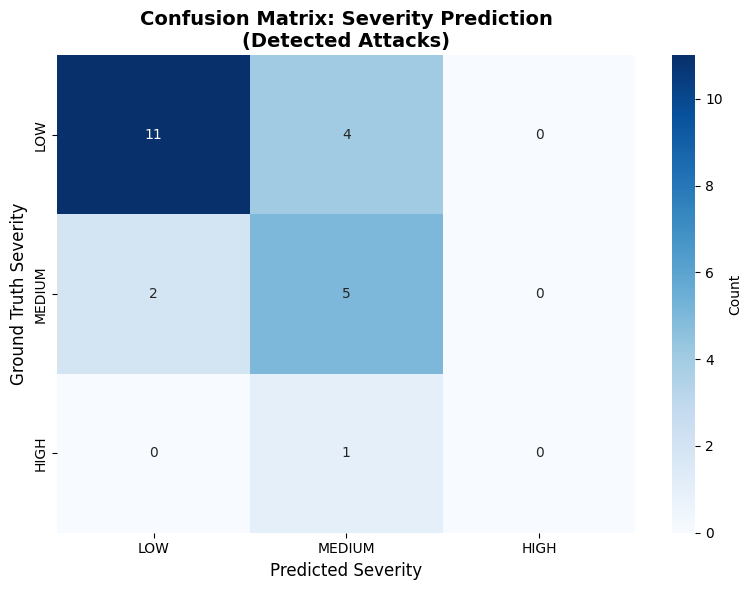


2. CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         LOW       0.85      0.73      0.79        15
      MEDIUM       0.50      0.71      0.59         7
        HIGH       0.00      0.00      0.00         1

    accuracy                           0.70        23
   macro avg       0.45      0.48      0.46        23
weighted avg       0.70      0.70      0.69        23


3. BAR CHART: Predicted vs Ground-Truth Severity


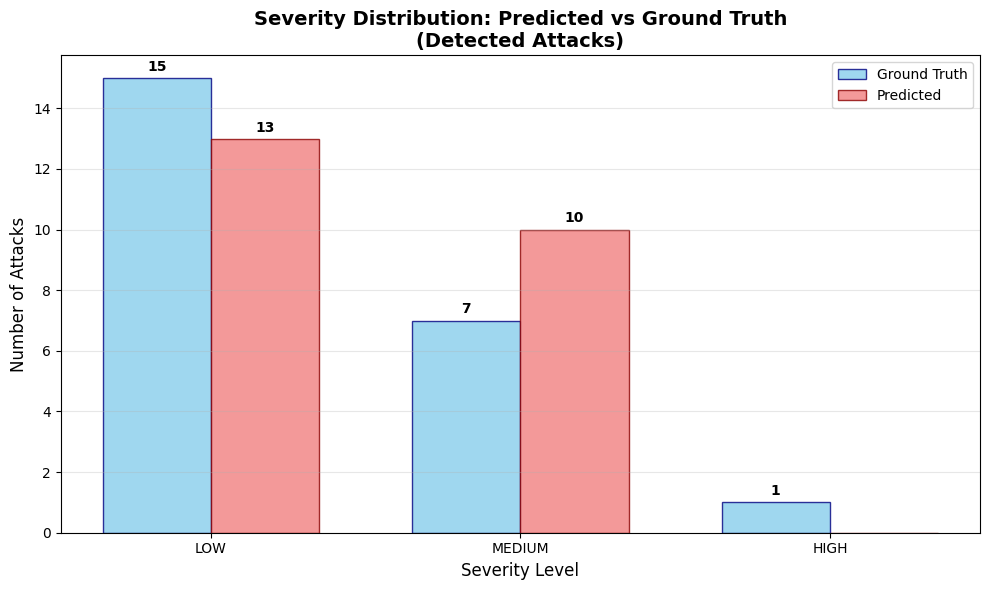


4. HEATMAP: Severity across Stages


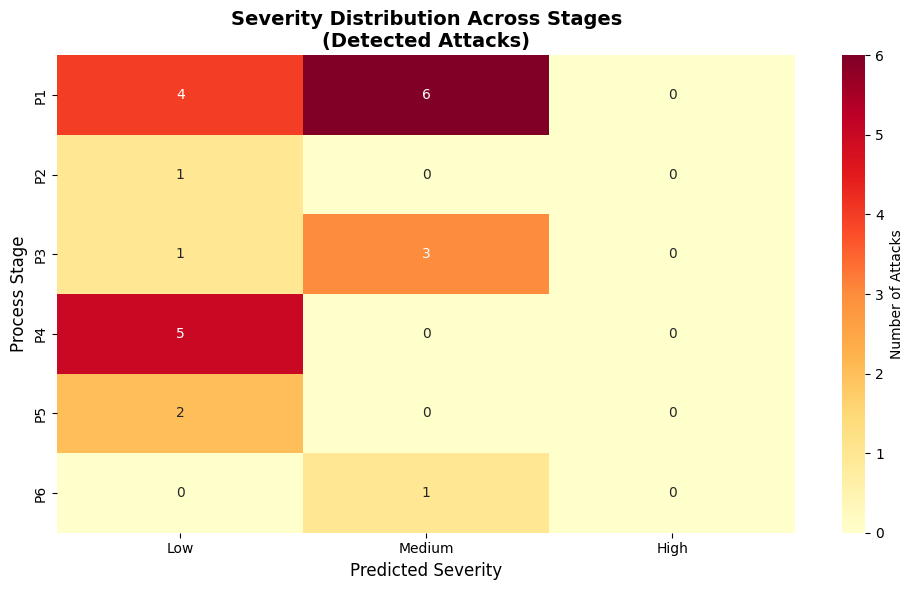


5. DETAILED STAGE ANALYSIS:
Severity  Low  Medium  High  Total
Stage                             
P1          4       6     0     10
P2          1       0     0      1
P3          1       3     0      4
P4          5       0     0      5
P5          2       0     0      2
P6          0       1     0      1

6. ATTACK DISTRIBUTION BY STAGE:


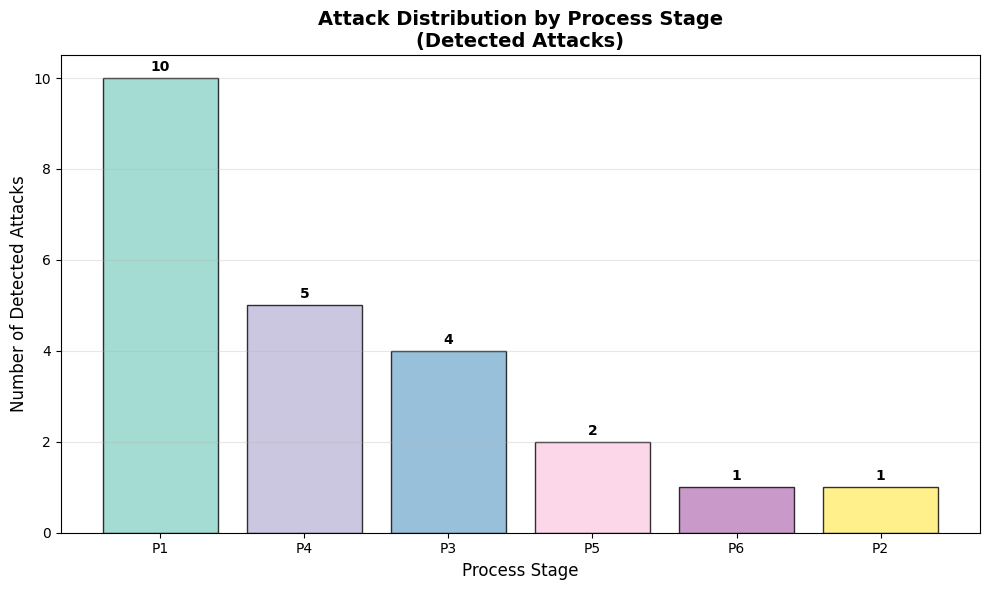


SUMMARY STATISTICS:
  Total attacks evaluated: 23
  Correctly classified: 16
  Accuracy: 0.696 (69.6%)

  Stage distribution of detected attacks:
    P1: 10 attacks (43.5%)
    P4: 5 attacks (21.7%)
    P3: 4 attacks (17.4%)
    P5: 2 attacks (8.7%)
    P6: 1 attacks (4.3%)
    P2: 1 attacks (4.3%)

  Misclassified attacks:
    Attack 2: GT=HIGH → Pred=Medium
    Attack 3: GT=LOW → Pred=Medium
    Attack 8: GT=LOW → Pred=Medium
    Attack 21: GT=MEDIUM → Pred=Low
    Attack 33: GT=MEDIUM → Pred=Low
    Attack 36: GT=LOW → Pred=Medium
    Attack 41: GT=LOW → Pred=Medium

VISUALIZATION AND EVALUATION COMPLETE


In [118]:
# results analysis display
if not top10_results_corrected.empty:
    # Filter out unknown ground truth for evaluation metrics
    eval_data = top10_results_corrected[top10_results_corrected['Ground_Truth'] != 'UNKNOWN'].copy()

    if not eval_data.empty:
        # Map SEVERE to HIGH for consistency
        eval_data['GT_Mapped'] = eval_data['Ground_Truth'].replace('SEVERE', 'HIGH')

        # Get actual and predicted labels
        y_true = eval_data['GT_Mapped'].values
        y_pred = eval_data['Predicted_Severity'].str.upper().values

        print(f"\n{'='*80}")
        print("EVALUATION METRICS FOR SEVERITY ANALYSIS")
        print(f"{'='*80}")

        # 1. CONFUSION MATRIX
        print("\n1. CONFUSION MATRIX:")
        from sklearn.metrics import confusion_matrix, classification_report

        # Define label order for consistent display
        labels = ['LOW', 'MEDIUM', 'HIGH']
        cm = confusion_matrix(y_true, y_pred, labels=labels)

        print(f"\nConfusion Matrix:")
        print(f"{'':>8} {'LOW':>6} {'MED':>6} {'HIGH':>6}")
        for i, true_label in enumerate(labels):
            row_str = f"{true_label:>8}"
            for j in range(len(labels)):
                row_str += f"{cm[i][j]:>6}"
            print(row_str)

        # Confusion Matrix Heatmap
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Count'})
        plt.title('Confusion Matrix: Severity Prediction\n(Detected Attacks)', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Severity', fontsize=12)
        plt.ylabel('Ground Truth Severity', fontsize=12)
        plt.tight_layout()
        plt.show()

        # 2. CLASSIFICATION REPORT
        print("\n2. CLASSIFICATION REPORT:")
        report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
        print(report)

        # 3. BAR CHART: Predicted vs Ground-Truth Severity
        print("\n3. BAR CHART: Predicted vs Ground-Truth Severity")

        # Count distributions
        gt_counts = eval_data['GT_Mapped'].value_counts().reindex(labels, fill_value=0)
        pred_counts = eval_data['Predicted_Severity'].str.upper().value_counts().reindex(labels, fill_value=0)

        # Create bar chart
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(labels))
        width = 0.35

        bars1 = ax.bar(x - width/2, gt_counts.values, width, label='Ground Truth',
                      color='skyblue', alpha=0.8, edgecolor='navy')
        bars2 = ax.bar(x + width/2, pred_counts.values, width, label='Predicted',
                      color='lightcoral', alpha=0.8, edgecolor='darkred')

        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.annotate(f'{int(height)}',
                               xy=(bar.get_x() + bar.get_width() / 2, height),
                               xytext=(0, 3),  # 3 points vertical offset
                               textcoords="offset points",
                               ha='center', va='bottom', fontweight='bold')

        ax.set_xlabel('Severity Level', fontsize=12)
        ax.set_ylabel('Number of Attacks', fontsize=12)
        ax.set_title('Severity Distribution: Predicted vs Ground Truth\n(Detected Attacks)',
                    fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

        # 4. HEATMAP: Severity across Stages
        print("\n4. HEATMAP: Severity across Stages")

        # Create stage mapping for detected attacks
        stage_severity_data = []
        for _, row in top10_results_corrected.iterrows():
            attack_num = row['Attack_Number']
            primary_point = row['Primary_Attack_Point']
            severity = row['Predicted_Severity']

            # Determine stage from primary attack point
            stage = 'Unknown'
            if primary_point in P1:
                stage = 'P1'
            elif primary_point in P2:
                stage = 'P2'
            elif primary_point in P3:
                stage = 'P3'
            elif primary_point in P4:
                stage = 'P4'
            elif primary_point in P5:
                stage = 'P5'
            elif primary_point in P6:
                stage = 'P6'

            stage_severity_data.append({
                'Attack': attack_num,
                'Stage': stage,
                'Severity': severity,
                'Primary_Point': primary_point
            })

        stage_severity_df = pd.DataFrame(stage_severity_data)

        # Create pivot table for heatmap
        severity_matrix = stage_severity_df.pivot_table(
            index='Stage',
            columns='Severity',
            values='Attack',
            aggfunc='count',
            fill_value=0
        )

        # Ensure all severity levels are present
        for sev in ['Low', 'Medium', 'High']:
            if sev not in severity_matrix.columns:
                severity_matrix[sev] = 0

        # Reorder columns
        severity_matrix = severity_matrix[['Low', 'Medium', 'High']]

        # Create heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(severity_matrix, annot=True, fmt='d', cmap='YlOrRd',
                   cbar_kws={'label': 'Number of Attacks'})
        plt.title('Severity Distribution Across Stages\n(Detected Attacks)',
                 fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Severity', fontsize=12)
        plt.ylabel('Process Stage', fontsize=12)
        plt.tight_layout()
        plt.show()

        # 5. DETAILED STAGE ANALYSIS TABLE
        print("\n5. DETAILED STAGE ANALYSIS:")
        stage_summary = stage_severity_df.groupby(['Stage', 'Severity']).size().unstack(fill_value=0)
        if 'Low' not in stage_summary.columns:
            stage_summary['Low'] = 0
        if 'Medium' not in stage_summary.columns:
            stage_summary['Medium'] = 0
        if 'High' not in stage_summary.columns:
            stage_summary['High'] = 0

        stage_summary = stage_summary[['Low', 'Medium', 'High']]
        stage_summary['Total'] = stage_summary.sum(axis=1)

        print(stage_summary.to_string())

        # 6. ATTACK DISTRIBUTION BY STAGE (Additional visualization)
        print("\n6. ATTACK DISTRIBUTION BY STAGE:")

        stage_counts = stage_severity_df['Stage'].value_counts()

        plt.figure(figsize=(10, 6))
        colors = plt.cm.Set3(np.linspace(0, 1, len(stage_counts)))
        bars = plt.bar(stage_counts.index, stage_counts.values, color=colors, alpha=0.8, edgecolor='black')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            plt.annotate(f'{int(height)}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontweight='bold')

        plt.xlabel('Process Stage', fontsize=12)
        plt.ylabel('Number of Detected Attacks', fontsize=12)
        plt.title('Attack Distribution by Process Stage\n(Detected Attacks)',
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

        # Print summary statistics
        print(f"\nSUMMARY STATISTICS:")
        print(f"  Total attacks evaluated: {len(eval_data)}")
        print(f"  Correctly classified: {sum(y_true == y_pred)}")
        print(f"  Accuracy: {sum(y_true == y_pred)/len(y_true):.3f} ({sum(y_true == y_pred)/len(y_true)*100:.1f}%)")

        # Stage distribution
        print(f"\n  Stage distribution of detected attacks:")
        for stage, count in stage_counts.items():
            percentage = (count / len(stage_severity_df)) * 100
            print(f"    {stage}: {count} attacks ({percentage:.1f}%)")

        # Show which attacks were misclassified
        misclassified = eval_data[eval_data['GT_Mapped'] != eval_data['Predicted_Severity'].str.upper()]
        if not misclassified.empty:
            print(f"\n  Misclassified attacks:")
            for _, row in misclassified.iterrows():
                print(f"    Attack {row['Attack_Number']}: GT={row['GT_Mapped']} → Pred={row['Predicted_Severity']}")
        else:
            print(f"\n  ✅ All attacks correctly classified!")

    else:
        print("\nNo ground truth data available for evaluation metrics.")

    print(f"\n{'='*80}")
    print("VISUALIZATION AND EVALUATION COMPLETE")
    print(f"{'='*80}")

else:
    print("No severity analysis results to visualize.")

In [119]:
print(top10_results_corrected[['Attack_Number','Predicted_Severity','Ground_Truth']].head())


   Attack_Number Predicted_Severity Ground_Truth
0              1             Medium       MEDIUM
1              2             Medium       SEVERE
2              3             Medium          LOW
3              8             Medium          LOW
4             11                Low          LOW


In [120]:
def print_attack_case_study(attack_num, results_df):
    """
    Print a detailed case study for one attack:
    stepwise calculation of severity score, operational disruption,
    safety criticality, and stage importance.
    """
    row = results_df[results_df['Attack_Number'] == attack_num]
    if row.empty:
        print(f"No data for Attack {attack_num}")
        return

    row = row.iloc[0]

    print("\n" + "="*80)
    print(f"CASE STUDY: Attack #{attack_num}")
    print("="*80)

    # Step 1: Identify primary attack point
    print(f"\n1) Primary Attack Point: {row['Primary_Attack_Point']}")
    print(f"   Ground Truth Severity: {row['Ground_Truth']}")

    # Step 2: Operational Disruption
    print("\n2) Operational Disruption Calculation:")
    print(f"   Raw Operational Disruption = {row['Operational_Disruption']:.4f}")
    print(f"   Normalized Operational Disruption = {row['Normalized_Op_Disruption']:.4f}")
    print("   → Based on top-10 most deviating components relative to baseline.")

    # Step 3: Safety Criticality
    print("\n3) Safety Criticality:")
    print(f"   Median safety weight of top-10 = {row['Safety_Criticality']:.4f}")

    # Step 4: Stage Importance
    print("\n4) Stage Importance:")
    print(f"   Median stage weight of top-10 = {row['Stage_Importance']:.4f}")

    # Step 5: Weighted Severity Score
    print("\n5) Final Severity Score Calculation:")
    print("   Formula = (0.15 × Norm. OD) + (0.50 × Safety Crit.) + (0.35 × Stage Imp.)")
    sev_score = row['Severity_Score']
    print(f"   → Severity Score = {sev_score:.4f}")

    # Step 6: Classification
    print("\n6) Classification:")
    print(f"   Predicted Severity = {row['Predicted_Severity']}")
    match = row['Match_GT']
    if match is True:
        print("   ✓ Prediction matches ground truth")
    elif match is False:
        print("   ✗ Prediction does NOT match ground truth")
    else:
        print("   (Prediction matches ground truth)")

    # Step 7: Key components
    print("\n7) Most affected components (Top-5):")
    comps = row.get('Top_5_Components', [])
    for i, c in enumerate(comps, 1):
        print(f"   {i}. {c}")

    print("\n" + "="*80)
    print("END OF CASE STUDY")
    print("="*80)


In [122]:
print_attack_case_study(17, top10_results_corrected)



CASE STUDY: Attack #17

1) Primary Attack Point: MV303
   Ground Truth Severity: MEDIUM

2) Operational Disruption Calculation:
   Raw Operational Disruption = 2.4132
   Normalized Operational Disruption = 0.3586
   → Based on top-10 most deviating components relative to baseline.

3) Safety Criticality:
   Median safety weight of top-10 = 0.7000

4) Stage Importance:
   Median stage weight of top-10 = 0.4500

5) Final Severity Score Calculation:
   Formula = (0.15 × Norm. OD) + (0.50 × Safety Crit.) + (0.35 × Stage Imp.)
   → Severity Score = 0.5521

6) Classification:
   Predicted Severity = Medium
   (Prediction matches ground truth)

7) Most affected components (Top-5):
   1. P602
   2. FIT601
   3. AIT502
   4. AIT501
   5. PIT502

END OF CASE STUDY


In [121]:
import numpy as np
import pandas as pd

def generate_simple_notifications(severity_results_df, time_label, test_scale):
    """
    Build a simple operator notification table from a severity results DataFrame.

    Required columns in severity_results_df:
      - 'Attack_Number' (int)
      - 'Predicted_Severity' (str: 'Low'|'Medium'|'High')
      - 'Primary_Attack_Point' (str)  [optional but recommended]
      - 'Selected_Components' (list[str]) [optional; used as a shortcut for main component]

    Args
    ----
    severity_results_df : pd.DataFrame
    time_label          : pd.DataFrame with a column 'attack #' (numeric) and matching index with test_scale
    test_scale          : pd.DataFrame (features x time) aligned by index with time_label

    Returns
    -------
    pd.DataFrame with columns:
      ['Attack_Number','Severity','Main_Component_Attacked','Primary_Attack_Point','Operator_Action']
    """
    # Basic sanity checks
    if severity_results_df is None or len(severity_results_df) == 0:
        return pd.DataFrame(columns=['Attack_Number','Severity','Main_Component_Attacked',
                                     'Primary_Attack_Point','Operator_Action'])
    if time_label is None or test_scale is None or len(test_scale) == 0:
        # If we cannot compute main component, still return notifications with 'Unknown'
        base_cols = ['Attack_Number','Predicted_Severity','Primary_Attack_Point']
        missing = [c for c in base_cols if c not in severity_results_df.columns]
        if missing:
            raise ValueError(f"severity_results_df missing columns: {missing}")
        out = []
        for _, r in severity_results_df.iterrows():
            sev = str(r['Predicted_Severity'])
            action = ("SHUTDOWN SYSTEM - Main component under attack: Unknown" if sev == "High"
                      else "MONITOR SYSTEM - Main component under attack: Unknown" if sev == "Medium"
                      else "CONTINUE NORMAL OPERATIONS - Minor impact on: Unknown")
            out.append({
                'Attack_Number': int(r['Attack_Number']),
                'Severity': sev,
                'Main_Component_Attacked': 'Unknown',
                'Primary_Attack_Point': r.get('Primary_Attack_Point', 'Unknown'),
                'Operator_Action': action
            })
        return pd.DataFrame(out)

    # Ensure required columns exist
    required_cols = ['Attack_Number','Predicted_Severity']
    missing = [c for c in required_cols if c not in severity_results_df.columns]
    if missing:
        raise ValueError(f"severity_results_df missing columns: {missing}")
    if 'attack #' not in time_label.columns:
        raise ValueError("time_label must contain column 'attack #'")

    EPS = 1e-9  # for CV denominator

    notifications = []

    for _, attack in severity_results_df.iterrows():
        attack_num = int(attack['Attack_Number'])
        severity   = str(attack['Predicted_Severity'])
        primary_attack_point = attack.get('Primary_Attack_Point', 'Unknown')

        # Fast path: if Top-10 routine already chose components, use the first
        main_component = 'Unknown'
        sel = attack.get('Selected_Components', None)
        if isinstance(sel, (list, tuple)) and len(sel) > 0 and isinstance(sel[0], str):
            main_component = sel[0]
        else:
            # Compute most volatile component within the attack window using CV = std / |median|
            # 1) find indices for this attack in time_label
            try:
                attack_mask = (time_label['attack #'] == attack_num)
                attack_idx = time_label.index[attack_mask]
                if len(attack_idx) > 0:
                    valid_positions = [pos for pos in attack_idx if pos in test_scale.index]
                    max_cv = -np.inf
                    # iterate features
                    for component in test_scale.columns:
                        try:
                            vals = test_scale.loc[valid_positions, component].astype(float)
                            if vals.notna().sum() >= 2:
                                med = float(np.nanmedian(vals))
                                std = float(np.nanstd(vals, ddof=1))  # sample std if possible
                                denom = max(abs(med), EPS)
                                cv = std / denom
                                if np.isfinite(cv) and cv > max_cv:
                                    max_cv = cv
                                    main_component = component
                        except Exception:
                            # Skip problematic component but continue
                            continue
                # else: keep 'Unknown'
            except Exception:
                # keep 'Unknown'
                pass

        # Map severity to operator action
        if severity == "High":
            recommendation = f"SHUTDOWN SYSTEM - Main component under attack: {main_component}"
        elif severity == "Medium":
            recommendation = f"MONITOR SYSTEM - Main component under attack: {main_component}"
        else:
            recommendation = f"CONTINUE NORMAL OPERATIONS - Minor impact on: {main_component}"

        notifications.append({
            'Attack_Number': attack_num,
            'Severity': severity,
            'Main_Component_Attacked': main_component,
            'Primary_Attack_Point': primary_attack_point,
            'Operator_Action': recommendation
        })

    return pd.DataFrame(notifications)


def print_simple_notifications(notifications_df):
    """
    Pretty-print notifications and a small summary. Safe on empty input.
    """
    print("\n" + "="*80)
    print("OPERATOR NOTIFICATION SYSTEM")
    print("="*80)

    if notifications_df is None or len(notifications_df) == 0:
        print("No security events detected")
        print("\n" + "="*60)
        print("NOTIFICATION COMPLETE")
        print("="*60)
        return

    print("\nSECURITY ALERTS:")
    print("-" * 60)

    for _, notification in notifications_df.iterrows():
        attack_num = notification['Attack_Number']
        severity = notification['Severity']
        action = notification['Operator_Action']
        print(f"Attack #{attack_num} | {severity.upper()} SEVERITY")
        print(f"ACTION: {action}")
        print("-" * 60)

    # Summary
    counts = notifications_df['Severity'].value_counts()
    high_count = int(counts.get('High', 0))
    medium_count = int(counts.get('Medium', 0))
    low_count = int(counts.get('Low', 0))

    print(f"\nSUMMARY: {high_count} High | {medium_count} Medium | {low_count} Low severity attacks")
    if high_count > 0:
        print("IMMEDIATE ACTION: System shutdown recommended")
    elif medium_count > 0:
        print("RECOMMENDED ACTION: Monitor system closely")
    else:
        print("RECOMMENDED ACTION: Continue normal operations")

    print("\n" + "="*60)
    print("NOTIFICATION COMPLETE")
    print("="*60)


In [126]:
# Choose whichever results object exists
_results_df = None
try:
    _results_df = top10_results_corrected
except NameError:
    pass
if _results_df is None:
    try:
        _results_df = top10_results
    except NameError:
        _results_df = None

if _results_df is not None and len(_results_df) > 0:
    simple_notifications = generate_simple_notifications(_results_df, time_label, test_scale)
    print_simple_notifications(simple_notifications)
else:
    print("No severity results available to generate notifications.")



OPERATOR NOTIFICATION SYSTEM

SECURITY ALERTS:
------------------------------------------------------------
Attack #1 | MEDIUM SEVERITY
ACTION: MONITOR SYSTEM - Main component under attack: FIT601
------------------------------------------------------------
Attack #2 | MEDIUM SEVERITY
ACTION: MONITOR SYSTEM - Main component under attack: P102
------------------------------------------------------------
Attack #3 | MEDIUM SEVERITY
ACTION: MONITOR SYSTEM - Main component under attack: FIT601
------------------------------------------------------------
Attack #8 | MEDIUM SEVERITY
ACTION: MONITOR SYSTEM - Main component under attack: P602
------------------------------------------------------------
Attack #11 | LOW SEVERITY
ACTION: CONTINUE NORMAL OPERATIONS - Minor impact on: P402
------------------------------------------------------------
Attack #17 | MEDIUM SEVERITY
ACTION: MONITOR SYSTEM - Main component under attack: P602
------------------------------------------------------------


In [123]:
# Detailed Case Study: Operational Disruption Calculation Analysis
def detailed_case_study_analysis(severity_results_df):
    """
    Provide detailed case study analysis for medium and low severity attacks
    with comprehensive operational disruption calculation explanation
    """

    # Get baseline medians from normal data
    normal_idx = time_label.index[time_label['label'] == 0]
    baseline_median = test_scale.iloc[normal_idx].median(axis=0)
    EPS = 1e-6

    print("DETAILED CASE STUDY: OPERATIONAL DISRUPTION CALCULATION")
    print("="*80)

    # Find one medium and one low severity example
    medium_examples = severity_results_df[severity_results_df['Predicted_Severity'] == 'Medium']
    low_examples = severity_results_df[severity_results_df['Predicted_Severity'] == 'Low']

    case_studies = []

    if not medium_examples.empty:
        medium_case = medium_examples.iloc[0]
        case_studies.append(('MEDIUM SEVERITY', medium_case))

    if not low_examples.empty:
        low_case = low_examples.iloc[0]
        case_studies.append(('LOW SEVERITY', low_case))

    for case_type, case_data in case_studies:
        print(f"\n{'*'*70}")
        print(f"CASE STUDY: {case_type} ATTACK")
        print(f"{'*'*70}")

        attack_num = case_data['Attack_Number']
        severity_score = case_data['Severity_Score']
        op_disruption = case_data['Operational_Disruption']
        safety_crit = case_data['Safety_Criticality']
        stage_imp = case_data['Stage_Importance']

        print(f"Attack Number: {attack_num}")
        print(f"Primary Attack Point: {case_data['Primary_Attack_Point']}")
        print(f"Ground Truth: {case_data['Ground_Truth']}")
        print(f"Predicted Severity: {case_data['Predicted_Severity']}")
        print(f"Final Severity Score: {severity_score:.6f}")

        # Get attack data for detailed analysis
        attack_mask = time_label['attack #'] == attack_num
        attack_data_indices = time_label.index[attack_mask]
        attack_positions = attack_data_indices.tolist()
        valid_positions = [pos for pos in attack_positions if pos < len(test_scale)]

        print(f"\n{'='*70}")
        print(f"STEP 1: BASELINE ESTABLISHMENT")
        print(f"{'='*70}")
        print(f"Normal data points used for baseline: {len(normal_idx)}")
        print(f"Attack data points analyzed: {len(valid_positions)}")

        # Calculate detailed component analysis
        component_analysis = []

        print(f"\n{'='*70}")
        print(f"STEP 2: COMPONENT-BY-COMPONENT DEVIATION ANALYSIS")
        print(f"{'='*70}")

        for component in test_scale.columns:
            try:
                # Get baseline median for this component
                baseline_val = float(baseline_median.get(component, 0.0))

                # Get attack period values for this component
                attack_vals = test_scale.iloc[valid_positions][component].dropna()

                if len(attack_vals) > 0:
                    # Calculate percentage deviations
                    denom = max(abs(baseline_val), EPS)
                    deviations = (attack_vals - baseline_val).abs() / denom

                    # Get statistics
                    max_deviation = deviations.max()
                    mean_deviation = deviations.mean()
                    median_deviation = deviations.median()

                    component_analysis.append({
                        'component': component,
                        'baseline_median': baseline_val,
                        'attack_mean': attack_vals.mean(),
                        'attack_median': attack_vals.median(),
                        'max_deviation': max_deviation,
                        'mean_deviation': mean_deviation,
                        'median_deviation': median_deviation,
                        'n_points': len(attack_vals)
                    })
            except:
                continue

        # Sort by max deviation to show most affected components
        component_analysis.sort(key=lambda x: x['max_deviation'], reverse=True)

        # Show top 10 most affected components
        print(f"\nTOP 10 MOST AFFECTED COMPONENTS:")
        print("-" * 70)
        header = f"{'Component':<15}{'Baseline':<12}{'Attack Avg':<12}{'Max Dev':<12}{'Mean Dev':<12}"
        print(header)
        print("-" * 70)

        top_10_analysis = component_analysis[:10]
        for comp in top_10_analysis:
            comp_name = comp['component'][:14]
            baseline = comp['baseline_median']
            attack_avg = comp['attack_mean']
            max_dev = comp['max_deviation']
            mean_dev = comp['mean_deviation']

            print(f"{comp_name:<15}{baseline:<12.4f}{attack_avg:<12.4f}{max_dev:<12.6f}{mean_dev:<12.6f}")

        print(f"\n{'='*70}")
        print(f"STEP 3: OPERATIONAL DISRUPTION CALCULATION")
        print(f"{'='*70}")

        # Calculate operational disruption as median of top 10 max deviations
        top_10_max_deviations = [comp['max_deviation'] for comp in top_10_analysis]
        calculated_op_disruption = np.median(top_10_max_deviations)

        print(f"Method: Median of top 10 components' maximum percentage deviations")
        print(f"Top 10 maximum deviations: {[f'{dev:.6f}' for dev in top_10_max_deviations]}")
        print(f"Median of these values: {calculated_op_disruption:.6f}")
        print(f"Recorded operational disruption: {op_disruption:.6f}")
        print(f"Match check: {'✓' if abs(calculated_op_disruption - op_disruption) < 1e-5 else '✗'}")

        print(f"\n{'='*70}")
        print(f"STEP 4: DEVIATION CALCULATION DETAILS")
        print(f"{'='*70}")

        # Show detailed calculation for top 3 components
        print(f"DETAILED CALCULATION FOR TOP 3 COMPONENTS:")
        print("-" * 50)

        for i, comp in enumerate(top_10_analysis[:3]):
            comp_name = comp['component']
            baseline = comp['baseline_median']
            attack_vals = test_scale.iloc[valid_positions][comp_name].dropna()

            print(f"\n{i+1}. Component: {comp_name}")
            print(f"   Baseline median (normal operation): {baseline:.6f}")
            print(f"   Attack period values: {len(attack_vals)} data points")
            print(f"   Attack period range: [{attack_vals.min():.6f}, {attack_vals.max():.6f}]")
            print(f"   Attack period mean: {attack_vals.mean():.6f}")

            # Show calculation step by step
            denom = max(abs(baseline), EPS)
            deviations = (attack_vals - baseline).abs() / denom

            print(f"   Percentage deviations calculation:")
            print(f"     Formula: |attack_value - baseline| / |baseline|")
            print(f"     Denominator: max(|{baseline:.6f}|, {EPS}) = {denom:.6f}")
            print(f"     Max deviation: {deviations.max():.6f}")
            print(f"     Mean deviation: {deviations.mean():.6f}")

        print(f"\n{'='*70}")
        print(f"STEP 5: SEVERITY SCORE COMPOSITION")
        print(f"{'='*70}")

        # Normalize operational disruption
        normalized_op = min(op_disruption, 1.0)  # Clipped to [0,1]

        # Calculate contributions
        op_contribution = normalized_op * 0.15
        safety_contribution = safety_crit * 0.50
        stage_contribution = stage_imp * 0.35

        print(f"Final Severity Score Breakdown:")
        print(f"  Operational Disruption: {op_disruption:.6f} → normalized: {normalized_op:.6f}")
        print(f"  Safety Criticality: {safety_crit:.6f}")
        print(f"  Stage Importance: {stage_imp:.6f}")
        print(f"")
        print(f"  Weighted Contributions:")
        print(f"    Operational (15%): {normalized_op:.6f} × 0.15 = {op_contribution:.6f}")
        print(f"    Safety (50%):       {safety_crit:.6f} × 0.50 = {safety_contribution:.6f}")
        print(f"    Stage (35%):        {stage_imp:.6f} × 0.35 = {stage_contribution:.6f}")
        print(f"    Total Severity:     {op_contribution:.6f} + {safety_contribution:.6f} + {stage_contribution:.6f} = {severity_score:.6f}")

        # Classification explanation
        if severity_score > 0.85:
            classification = "High"
            threshold_info = "Score > 0.85"
        elif severity_score > 0.55:
            classification = "Medium"
            threshold_info = "0.55 < Score ≤ 0.85"
        else:
            classification = "Low"
            threshold_info = "Score ≤ 0.55"

        print(f"")
        print(f"  Classification: {classification} ({threshold_info})")

        print(f"\n{'='*70}")
        print(f"STEP 6: INTERPRETATION")
        print(f"{'='*70}")

        print(f"Key Insights for Attack #{attack_num}:")
        print(f"• Operational Impact: {op_disruption:.1%} average deviation from normal operation")
        print(f"• Most affected component: {top_10_analysis[0]['component']} (deviation: {top_10_analysis[0]['max_deviation']:.1%})")
        print(f"• Safety risk level: {'High' if safety_crit > 0.7 else 'Medium' if safety_crit > 0.4 else 'Low'}")
        print(f"• Process stage criticality: {'High' if stage_imp > 0.7 else 'Medium' if stage_imp > 0.4 else 'Low'}")

        if op_disruption > 0.5:
            print(f"• High operational disruption indicates significant system-wide impact")
        elif op_disruption > 0.2:
            print(f"• Moderate operational disruption suggests localized but measurable impact")
        else:
            print(f"• Low operational disruption indicates minimal system-wide effects")

# Execute detailed case study analysis
if 'top10_results_corrected' in locals() and not top10_results_corrected.empty:
    detailed_case_study_analysis(top10_results_corrected)
else:
    print("No corrected severity analysis results available for case study.")
    print("Please run the corrected top 10 analysis first.")

print(f"\n{'='*80}")
print("DETAILED CASE STUDY ANALYSIS COMPLETE")
print(f"{'='*80}")

DETAILED CASE STUDY: OPERATIONAL DISRUPTION CALCULATION

**********************************************************************
CASE STUDY: MEDIUM SEVERITY ATTACK
**********************************************************************
Attack Number: 1
Primary Attack Point: MV101
Ground Truth: MEDIUM
Predicted Severity: Medium
Final Severity Score: 0.459348

STEP 1: BASELINE ESTABLISHMENT
Normal data points used for baseline: 395298
Attack data points analyzed: 954

STEP 2: COMPONENT-BY-COMPONENT DEVIATION ANALYSIS

TOP 10 MOST AFFECTED COMPONENTS:
----------------------------------------------------------------------
Component      Baseline    Attack Avg  Max Dev     Mean Dev    
----------------------------------------------------------------------
FIT601         0.0000      0.0001      73.391973   73.391973   
AIT502         0.0036      0.0497      19.395476   12.911985   
AIT501         -0.0689     0.5626      9.399825    9.168419    
LIT101         0.1215      1.1327      8.565848  

In [124]:
# Detailed Case Study: Operational Disruption Calculation Analysis
def detailed_case_study_analysis(severity_results_df):
    """
    Provide detailed case study analysis for medium and low severity attacks
    with comprehensive operational disruption calculation explanation
    """

    # Get baseline medians from normal data
    normal_idx = time_label.index[time_label['label'] == 0]
    baseline_median = test_scale.iloc[normal_idx].median(axis=0)
    EPS = 1e-6

    print("DETAILED CASE STUDY: OPERATIONAL DISRUPTION CALCULATION")
    print("="*80)

    # Find one medium and one low severity example
    medium_examples = severity_results_df[severity_results_df['Predicted_Severity'] == 'Medium']
    low_examples = severity_results_df[severity_results_df['Predicted_Severity'] == 'Low']

    case_studies = []

    if not medium_examples.empty:
        medium_case = medium_examples.iloc[0]
        case_studies.append(('MEDIUM SEVERITY', medium_case))

    if not low_examples.empty:
        low_case = low_examples.iloc[0]
        case_studies.append(('LOW SEVERITY', low_case))

    for case_type, case_data in case_studies:
        print(f"\n{'*'*70}")
        print(f"CASE STUDY: {case_type} ATTACK")
        print(f"{'*'*70}")

        attack_num = case_data['Attack_Number']
        severity_score = case_data['Severity_Score']
        op_disruption = case_data['Operational_Disruption']
        safety_crit = case_data['Safety_Criticality']
        stage_imp = case_data['Stage_Importance']

        print(f"Attack Number: {attack_num}")
        print(f"Primary Attack Point: {case_data['Primary_Attack_Point']}")
        print(f"Ground Truth: {case_data['Ground_Truth']}")
        print(f"Predicted Severity: {case_data['Predicted_Severity']}")
        print(f"Final Severity Score: {severity_score:.6f}")

        # Get attack data for detailed analysis
        attack_mask = time_label['attack #'] == attack_num
        attack_data_indices = time_label.index[attack_mask]
        attack_positions = attack_data_indices.tolist()
        valid_positions = [pos for pos in attack_positions if pos < len(test_scale)]

        print(f"\n{'='*70}")
        print(f"STEP 1: BASELINE ESTABLISHMENT")
        print(f"{'='*70}")
        print(f"Normal data points used for baseline: {len(normal_idx)}")
        print(f"Attack data points analyzed: {len(valid_positions)}")

        # Calculate detailed component analysis
        component_analysis = []

        print(f"\n{'='*70}")
        print(f"STEP 2: COMPONENT-BY-COMPONENT DEVIATION ANALYSIS")
        print(f"{'='*70}")

        for component in test_scale.columns:
            try:
                # Get baseline median for this component
                baseline_val = float(baseline_median.get(component, 0.0))

                # Get attack period values for this component
                attack_vals = test_scale.iloc[valid_positions][component].dropna()

                if len(attack_vals) > 0:
                    # Calculate percentage deviations
                    denom = max(abs(baseline_val), EPS)
                    deviations = (attack_vals - baseline_val).abs() / denom

                    # Get statistics
                    max_deviation = deviations.max()
                    mean_deviation = deviations.mean()
                    median_deviation = deviations.median()

                    component_analysis.append({
                        'component': component,
                        'baseline_median': baseline_val,
                        'attack_mean': attack_vals.mean(),
                        'attack_median': attack_vals.median(),
                        'max_deviation': max_deviation,
                        'mean_deviation': mean_deviation,
                        'median_deviation': median_deviation,
                        'n_points': len(attack_vals)
                    })
            except:
                continue

        # Sort by max deviation to show most affected components
        component_analysis.sort(key=lambda x: x['max_deviation'], reverse=True)

        # Show top 10 most affected components
        print(f"\nTOP 10 MOST AFFECTED COMPONENTS:")
        print("-" * 70)
        header = f"{'Component':<15}{'Baseline':<12}{'Attack Avg':<12}{'Max Dev':<12}{'Mean Dev':<12}"
        print(header)
        print("-" * 70)

        top_10_analysis = component_analysis[:10]
        for comp in top_10_analysis:
            comp_name = comp['component'][:14]
            baseline = comp['baseline_median']
            attack_avg = comp['attack_mean']
            max_dev = comp['max_deviation']
            mean_dev = comp['mean_deviation']

            print(f"{comp_name:<15}{baseline:<12.4f}{attack_avg:<12.4f}{max_dev:<12.6f}{mean_dev:<12.6f}")

        print(f"\n{'='*70}")
        print(f"STEP 3: OPERATIONAL DISRUPTION CALCULATION")
        print(f"{'='*70}")

        # Calculate operational disruption as median of top 10 max deviations
        top_10_max_deviations = [comp['max_deviation'] for comp in top_10_analysis]
        calculated_op_disruption = np.median(top_10_max_deviations)

        print(f"Method: Median of top 10 components' maximum percentage deviations")
        print(f"Top 10 maximum deviations: {[f'{dev:.6f}' for dev in top_10_max_deviations]}")
        print(f"Median of these values: {calculated_op_disruption:.6f}")
        print(f"Recorded operational disruption: {op_disruption:.6f}")
        print(f"Match check: {'✓' if abs(calculated_op_disruption - op_disruption) < 1e-5 else '✗'}")

        print(f"\n{'='*70}")
        print(f"STEP 4: DEVIATION CALCULATION DETAILS")
        print(f"{'='*70}")

        # Show detailed calculation for top 3 components
        print(f"DETAILED CALCULATION FOR TOP 3 COMPONENTS:")
        print("-" * 50)

        for i, comp in enumerate(top_10_analysis[:3]):
            comp_name = comp['component']
            baseline = comp['baseline_median']
            attack_vals = test_scale.iloc[valid_positions][comp_name].dropna()

            print(f"\n{i+1}. Component: {comp_name}")
            print(f"   Baseline median (normal operation): {baseline:.6f}")
            print(f"   Attack period values: {len(attack_vals)} data points")
            print(f"   Attack period range: [{attack_vals.min():.6f}, {attack_vals.max():.6f}]")
            print(f"   Attack period mean: {attack_vals.mean():.6f}")

            # Show calculation step by step
            denom = max(abs(baseline), EPS)
            deviations = (attack_vals - baseline).abs() / denom

            print(f"   Percentage deviations calculation:")
            print(f"     Formula: |attack_value - baseline| / |baseline|")
            print(f"     Denominator: max(|{baseline:.6f}|, {EPS}) = {denom:.6f}")
            print(f"     Max deviation: {deviations.max():.6f}")
            print(f"     Mean deviation: {deviations.mean():.6f}")

        print(f"\n{'='*70}")
        print(f"STEP 5: SEVERITY SCORE COMPOSITION")
        print(f"{'='*70}")

        # Normalize operational disruption
        normalized_op = min(op_disruption, 1.0)  # Clipped to [0,1]

        # Calculate contributions
        op_contribution = normalized_op * 0.15
        safety_contribution = safety_crit * 0.50
        stage_contribution = stage_imp * 0.35

        print(f"Final Severity Score Breakdown:")
        print(f"  Operational Disruption: {op_disruption:.6f} → normalized: {normalized_op:.6f}")
        print(f"  Safety Criticality: {safety_crit:.6f}")
        print(f"  Stage Importance: {stage_imp:.6f}")
        print(f"")
        print(f"  Weighted Contributions:")
        print(f"    Operational (15%): {normalized_op:.6f} × 0.15 = {op_contribution:.6f}")
        print(f"    Safety (50%):       {safety_crit:.6f} × 0.50 = {safety_contribution:.6f}")
        print(f"    Stage (35%):        {stage_imp:.6f} × 0.35 = {stage_contribution:.6f}")
        print(f"    Total Severity:     {op_contribution:.6f} + {safety_contribution:.6f} + {stage_contribution:.6f} = {severity_score:.6f}")

        # Classification explanation
        if severity_score > 0.85:
            classification = "High"
            threshold_info = "Score > 0.85"
        elif severity_score > 0.55:
            classification = "Medium"
            threshold_info = "0.55 < Score ≤ 0.85"
        else:
            classification = "Low"
            threshold_info = "Score ≤ 0.55"

        print(f"")
        print(f"  Classification: {classification} ({threshold_info})")

        print(f"\n{'='*70}")
        print(f"STEP 6: INTERPRETATION")
        print(f"{'='*70}")

        print(f"Key Insights for Attack #{attack_num}:")
        print(f"• Operational Impact: {op_disruption:.1%} average deviation from normal operation")
        print(f"• Most affected component: {top_10_analysis[0]['component']} (deviation: {top_10_analysis[0]['max_deviation']:.1%})")
        print(f"• Safety risk level: {'High' if safety_crit > 0.7 else 'Medium' if safety_crit > 0.4 else 'Low'}")
        print(f"• Process stage criticality: {'High' if stage_imp > 0.7 else 'Medium' if stage_imp > 0.4 else 'Low'}")

        if op_disruption > 0.5:
            print(f"• High operational disruption indicates significant system-wide impact")
        elif op_disruption > 0.2:
            print(f"• Moderate operational disruption suggests localized but measurable impact")
        else:
            print(f"• Low operational disruption indicates minimal system-wide effects")

# Execute detailed case study analysis
if 'top10_results_corrected' in locals() and not top10_results_corrected.empty:
    detailed_case_study_analysis(top10_results_corrected)
else:
    print("No corrected severity analysis results available for case study.")
    print("Please run the corrected top 10 analysis first.")

print(f"\n{'='*80}")
print("DETAILED CASE STUDY ANALYSIS COMPLETE")
print(f"{'='*80}")

DETAILED CASE STUDY: OPERATIONAL DISRUPTION CALCULATION

**********************************************************************
CASE STUDY: MEDIUM SEVERITY ATTACK
**********************************************************************
Attack Number: 1
Primary Attack Point: MV101
Ground Truth: MEDIUM
Predicted Severity: Medium
Final Severity Score: 0.459348

STEP 1: BASELINE ESTABLISHMENT
Normal data points used for baseline: 395298
Attack data points analyzed: 954

STEP 2: COMPONENT-BY-COMPONENT DEVIATION ANALYSIS

TOP 10 MOST AFFECTED COMPONENTS:
----------------------------------------------------------------------
Component      Baseline    Attack Avg  Max Dev     Mean Dev    
----------------------------------------------------------------------
FIT601         0.0000      0.0001      73.391973   73.391973   
AIT502         0.0036      0.0497      19.395476   12.911985   
AIT501         -0.0689     0.5626      9.399825    9.168419    
LIT101         0.1215      1.1327      8.565848  

In [127]:
import pandas as pd

# --- 1) Start from results dataframe ---
df = _results_df.copy()  # <-- uses  existing dataframe

# --- 2) Add Stage from stage_severity_df  ---
if 'stage_severity_df' in globals():
    stage_map = stage_severity_df[['Attack', 'Stage']].drop_duplicates()
    df = df.merge(stage_map, left_on='Attack_Number', right_on='Attack', how='left')
    if 'Attack' in df.columns:
        df = df.drop(columns=['Attack'])

# --- 3) Create Severity_Band (use  Predicted_Severity as the band) ---
df['Severity_Band'] = df['Predicted_Severity'].astype(str).str.title()

# --- 4) Build Operator_Notification with band + component ---
def build_notification(row):
    band = row['Severity_Band']
    point = row['Primary_Attack_Point']
    stage_txt = f" (Stage {row['Stage']})" if 'Stage' in row and pd.notna(row['Stage']) else ""

    # Simple recommended actions by band
    if band.lower() == 'high':
        action = "ISOLATE affected loop and escalate to supervisor immediately."
    elif band.lower() == 'medium':
        action = "Monitor closely, verify setpoints/interlocks, and prepare mitigation."
    else:  # low
        action = "Log the event and continue monitoring."

    return f"{band} severity attack detected at {point}{stage_txt}. RECOMMENDED ACTION: {action}"

df['Operator_Notification'] = df.apply(build_notification, axis=1)

# --- 5) Keep only requested columns & sort by decreasing severity score ---
out = (
    df[['Attack_Number', 'Severity_Score', 'Severity_Band', 'Operator_Notification']]
    .sort_values(by='Severity_Score', ascending=False)
    .reset_index(drop=True)
)

# --- 6) Display ---
out  # In notebooks this will render a clean table


,Attack_Number,Severity_Score,Severity_Band,Operator_Notification
0,30,0.604305,Medium,Medium severity attack detected at LIT101 (Sta...
1,8,0.575353,Medium,Medium severity attack detected at DPIT301 (St...
2,23,0.570906,Medium,Medium severity attack detected at P602 (Stage...
3,35,0.556711,Medium,Medium severity attack detected at P101 (Stage...
4,17,0.552149,Medium,Medium severity attack detected at MV303 (Stag...
5,41,0.465233,Medium,Medium severity attack detected at LIT301 (Sta...
6,2,0.464185,Medium,Medium severity attack detected at P102 (Stage...
7,1,0.459348,Medium,Medium severity attack detected at MV101 (Stag...
8,3,0.455689,Medium,Medium severity attack detected at LIT101 (Sta...
9,36,0.454821,Medium,Medium severity attack detected at LIT101 (Sta...
